# **Problem Statement**

## Business Context

Renewable energy sources play an increasingly important role in the global energy mix, as the effort to reduce the environmental impact of energy production increases.

Out of all the renewable energy alternatives, wind energy is one of the most developed technologies worldwide. The U.S Department of Energy has put together a guide to achieving operational efficiency using predictive maintenance practices.

Predictive maintenance uses sensor information and analysis methods to measure and predict degradation and future component capability. The idea behind predictive maintenance is that failure patterns are predictable and if component failure can be predicted accurately and the component is replaced before it fails, the costs of operation and maintenance will be much lower.

The sensors fitted across different machines involved in the process of energy generation collect data related to various environmental factors (temperature, humidity, wind speed, etc.) and additional features related to various parts of the wind turbine (gearbox, tower, blades, break, etc.).

## Objective

“ReneWind” is a company working on improving the machinery/processes involved in the production of wind energy using machine learning and has collected data of generator failure of wind turbines using sensors. They have shared a ciphered version of the data, as the data collected through sensors is confidential (the type of data collected varies with companies). Data has 40 predictors, 20000 observations in the training set and 5000 in the test set.

The objective is to build various classification models, tune them, and find the best one that will help identify failures so that the generators could be repaired before failing/breaking to reduce the overall maintenance cost.
The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model. These will result in repairing costs.
- False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
- False positives (FP) are detections where there is no failure. These will result in inspection costs.

It is given that the cost of repairing a generator is much less than the cost of replacing it, and the cost of inspection is less than the cost of repair.

“1” in the target variables should be considered as “failure” and “0” represents “No failure”.

## Data Description

The data provided is a transformed version of the original data which was collected using sensors.

- Train.csv - To be used for training and tuning of models.
- Test.csv - To be used only for testing the performance of the final best model.

Both the datasets consist of 40 predictor variables and 1 target variable.

# **Installing and Importing the necessary libraries**

In [313]:
# Installing the libraries with the specified version
!pip install --no-deps tensorflow==2.19.0 scikit-learn==1.6.1 matplotlib===3.10.0 seaborn==0.13.2 numpy==2.0.2 pandas==2.2.2 -q --user --no-warn-script-location

In [314]:
import warnings

warnings.filterwarnings("ignore")

#import librarires for data access and manipulation
import numpy as np
import pandas as pd

#import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

#import libraries to split data
from sklearn.model_selection import train_test_split

#data preprocessing
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#dataset imputation
from sklearn.impute import SimpleImputer

#libraries for model building
import tensorflow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from tensorflow.keras import backend

# Libraries to get different metric scores
from sklearn import metrics
from sklearn.metrics import (
  confusion_matrix,
  accuracy_score,
  precision_score,
  recall_score,
  f1_score,
  classification_report
)

#time functions
import time

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

# **Loading the Data**

In [315]:
# uncomment and run the following lines for Google Colab
from google.colab import drive
drive.mount('/content/drive')

#import data
renewind_data = pd.read_csv("/content/drive/MyDrive/AIML/Train.csv")
renewind_data_test = pd.read_csv("/content/drive/MyDrive/AIML/Test.csv")

# create a copy of data

data = renewind_data.copy()
data_test = renewind_data_test.copy()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Data Overview**

### Viewing the first and last 5 rows of the dataset

In [316]:
data.head(5)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-4.464606,-4.679129,3.101546,0.506130,-0.221083,-2.032511,-2.910870,0.050714,-1.522351,3.761892,...,3.059700,-1.690440,2.846296,2.235198,6.667486,0.443809,-2.369169,2.950578,-3.480324,0
1,3.365912,3.653381,0.909671,-1.367528,0.332016,2.358938,0.732600,-4.332135,0.565695,-0.101080,...,-1.795474,3.032780,-2.467514,1.894599,-2.297780,-1.731048,5.908837,-0.386345,0.616242,0
2,-3.831843,-5.824444,0.634031,-2.418815,-1.773827,1.016824,-2.098941,-3.173204,-2.081860,5.392621,...,-0.257101,0.803550,4.086219,2.292138,5.360850,0.351993,2.940021,3.839160,-4.309402,0
3,1.618098,1.888342,7.046143,-1.147285,0.083080,-1.529780,0.207309,-2.493629,0.344926,2.118578,...,-3.584425,-2.577474,1.363769,0.622714,5.550100,-1.526796,0.138853,3.101430,-1.277378,0
4,-0.111440,3.872488,-3.758361,-2.982897,3.792714,0.544960,0.205433,4.848994,-1.854920,-6.220023,...,8.265896,6.629213,-10.068689,1.222987,-3.229763,1.686909,-2.163896,-3.644622,6.510338,0


In [317]:
data.tail(5)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
19995,-2.071318,-1.088279,-0.796174,-3.011720,-2.287540,2.807310,0.481428,0.105171,-0.586599,-2.899398,...,-8.273996,5.745013,0.589014,-0.649988,-3.043174,2.216461,0.608723,0.178193,2.927755,1
19996,2.890264,2.483069,5.643919,0.937053,-1.380870,0.412051,-1.593386,-5.762498,2.150096,0.272302,...,-4.159092,1.181466,-0.742412,5.368979,-0.693028,-1.668971,3.659954,0.819863,-1.987265,0
19997,-3.896979,-3.942407,-0.351364,-2.417462,1.107546,-1.527623,-3.519882,2.054792,-0.233996,-0.357687,...,7.112162,1.476080,-3.953710,1.855555,5.029209,2.082588,-6.409304,1.477138,-0.874148,0
19998,-3.187322,-10.051662,5.695955,-4.370053,-5.354758,-1.873044,-3.947210,0.679420,-2.389254,5.456756,...,0.402812,3.163661,3.752095,8.529894,8.450626,0.203958,-7.129918,4.249394,-6.112267,0
19999,-2.686903,1.961187,6.137088,2.600133,2.657241,-4.290882,-2.344267,0.974004,-1.027462,0.497421,...,6.620811,-1.988786,-1.348901,3.951801,5.449706,-0.455411,-2.202056,1.678229,-1.974413,0


* Observations

* Sanity checks

### Checking the shape of the dataset.

In [318]:
data.shape

(20000, 41)

- The dataset has 20000 rows and 41 columns.



In [319]:
data_test.shape

(5000, 41)

- The dataset has 5000 rows and 41 columns.



### Checking the attribute types

In [320]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      19982 non-null  float64
 1   V2      19982 non-null  float64
 2   V3      20000 non-null  float64
 3   V4      20000 non-null  float64
 4   V5      20000 non-null  float64
 5   V6      20000 non-null  float64
 6   V7      20000 non-null  float64
 7   V8      20000 non-null  float64
 8   V9      20000 non-null  float64
 9   V10     20000 non-null  float64
 10  V11     20000 non-null  float64
 11  V12     20000 non-null  float64
 12  V13     20000 non-null  float64
 13  V14     20000 non-null  float64
 14  V15     20000 non-null  float64
 15  V16     20000 non-null  float64
 16  V17     20000 non-null  float64
 17  V18     20000 non-null  float64
 18  V19     20000 non-null  float64
 19  V20     20000 non-null  float64
 20  V21     20000 non-null  float64
 21  V22     20000 non-null  float64
 22

* 40 predictor variables (V1–V40)
* 1 target variable (`Target`)
* All predictors are numerical (`float64`)
* Target variable is integer (`int64`)
* No categorical or object-type features
* Dataset is mostly clean with minimal missing data


In [321]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      4995 non-null   float64
 1   V2      4994 non-null   float64
 2   V3      5000 non-null   float64
 3   V4      5000 non-null   float64
 4   V5      5000 non-null   float64
 5   V6      5000 non-null   float64
 6   V7      5000 non-null   float64
 7   V8      5000 non-null   float64
 8   V9      5000 non-null   float64
 9   V10     5000 non-null   float64
 10  V11     5000 non-null   float64
 11  V12     5000 non-null   float64
 12  V13     5000 non-null   float64
 13  V14     5000 non-null   float64
 14  V15     5000 non-null   float64
 15  V16     5000 non-null   float64
 16  V17     5000 non-null   float64
 17  V18     5000 non-null   float64
 18  V19     5000 non-null   float64
 19  V20     5000 non-null   float64
 20  V21     5000 non-null   float64
 21  V22     5000 non-null   float64
 22  

- There are 40 numerical predictor variables (V1–V40) and 1 integer target variable (Target).

- V1 and V2 contain a small number of missing values; all other columns are complete.

- All predictors are of type float64, indicating fully numerical feature space.

### Checking the statistical summary

In [322]:
data.describe(include="all")

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
count,19982.000000,19982.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,-0.271996,0.440430,2.484699,-0.083152,-0.053752,-0.995443,-0.879325,-0.548195,-0.016808,-0.012998,...,0.303799,0.049825,-0.462702,2.229620,1.514809,0.011316,-0.344025,0.890653,-0.875630,0.055500
std,3.441625,3.150784,3.388963,3.431595,2.104801,2.040970,1.761626,3.295756,2.160568,2.193201,...,5.500400,3.575285,3.183841,2.937102,3.800860,1.788165,3.948147,1.753054,3.012155,0.228959
min,-11.876451,-12.319951,-10.708139,-15.082052,-8.603361,-10.227147,-7.949681,-15.657561,-8.596313,-9.853957,...,-19.876502,-16.898353,-17.985094,-15.349803,-14.833178,-5.478350,-17.375002,-6.438880,-11.023935,0.000000
25%,-2.737146,-1.640674,0.206860,-2.347660,-1.535607,-2.347238,-2.030926,-2.642665,-1.494973,-1.411212,...,-3.420469,-2.242857,-2.136984,0.336191,-0.943809,-1.255819,-2.987638,-0.272250,-2.940193,0.000000
50%,-0.747917,0.471536,2.255786,-0.135241,-0.101952,-1.000515,-0.917179,-0.389085,-0.067597,0.100973,...,0.052073,-0.066249,-0.255008,2.098633,1.566526,-0.128435,-0.316849,0.919261,-0.920806,0.000000
75%,1.840112,2.543967,4.566165,2.130615,1.340480,0.380330,0.223695,1.722965,1.409203,1.477045,...,3.761722,2.255134,1.436935,4.064358,3.983939,1.175533,2.279399,2.057540,1.119897,0.000000
max,15.493002,13.089269,17.090919,13.236381,8.133797,6.975847,8.006091,11.679495,8.137580,8.108472,...,23.633187,16.692486,14.358213,15.291065,19.329576,7.467006,15.289923,7.759877,10.654265,1.000000


* Dataset contains 20,000 observations; only `V1` and `V2` have 18 missing values each, others are complete.
* `Target` is binary (0–1) with mean ≈ 0.0555 → strong class imbalance (~5.5% positive class).
* Several features show large ranges and high standard deviations (e.g., `V32`, `V16`), indicating potential outliers.
* Noticeable differences between mean and median in multiple variables suggest skewed distributions.
* Overall feature distributions are similar to the previous dataset but with more stable estimates due to larger sample size.


### Checking for missing values

In [323]:
# checking for null values
data.isnull().sum()

,0
V1,18
V2,18
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


- V1 and V2  contain missing values (18); all other variables are complete

### Checking for duplicate values

In [324]:
# checking for duplicate values
data.duplicated().sum()

np.int64(0)

* There are no duplicate values in the data.

# **Exploratory Data Analysis**

## Univariate analysis

In [325]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
  """
  Boxplot and histogram combined

  data: dataframe
  feature: dataframe column
  figsize: size of figure (default (15,10))
  kde: whether to show the density curve (default False)
  bins: number of bins for histogram (default None)
  """

  f2, (ax_box2, ax_hist2) = plt.subplots(
    nrows=2, # Number of rows of the subplot grid= 2
    sharex=True, # x-axis will be shared among all subplots
    gridspec_kw={"height_ratios": (0.25, 0.75)},
    figsize=figsize
  )
  # creating the 2 subplots
  sns.boxplot(
    data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
  ) # boxplot will be created and a triangle will indicate the mean value of the column
  sns.histplot(
    data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
  ) if bins else sns.histplot(
      data=data, x=feature, kde=kde, ax=ax_hist2
  ) # For histogram
  ax_hist2.axvline(
  data[feature].mean(), color="green", linestyle="--"
  ) # Add mean to the histogram
  ax_hist2.axvline(
  data[feature].median(), color="black", linestyle="-"
  ) # Add median to the histogram

### The Predictor Variable (V1 - V40)

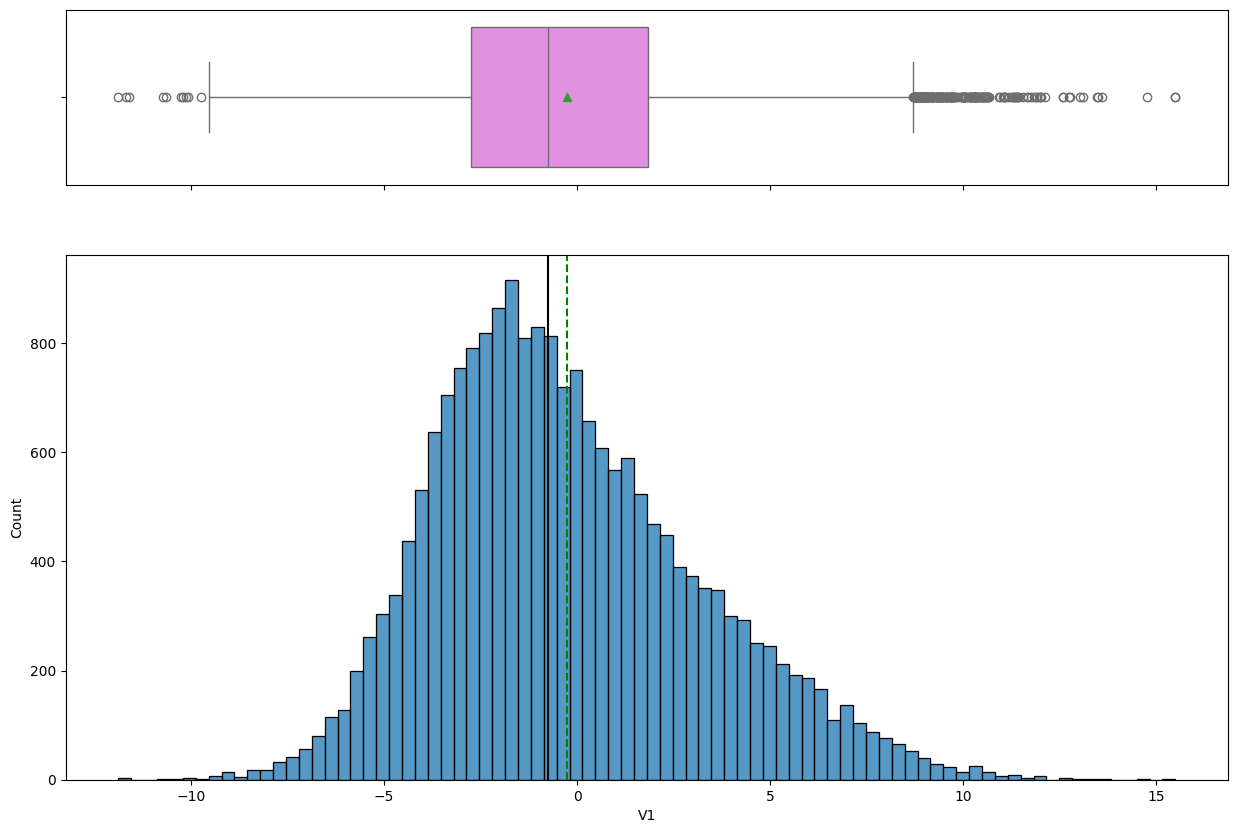

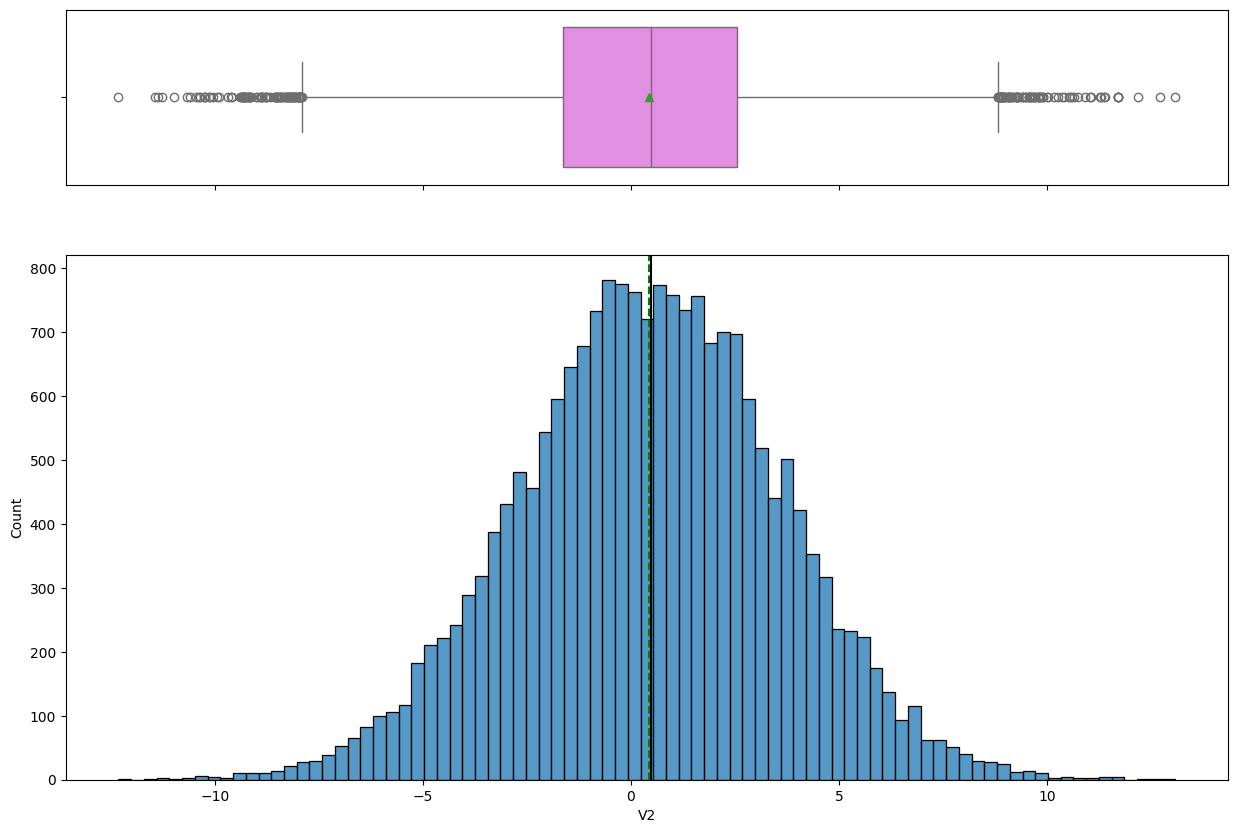

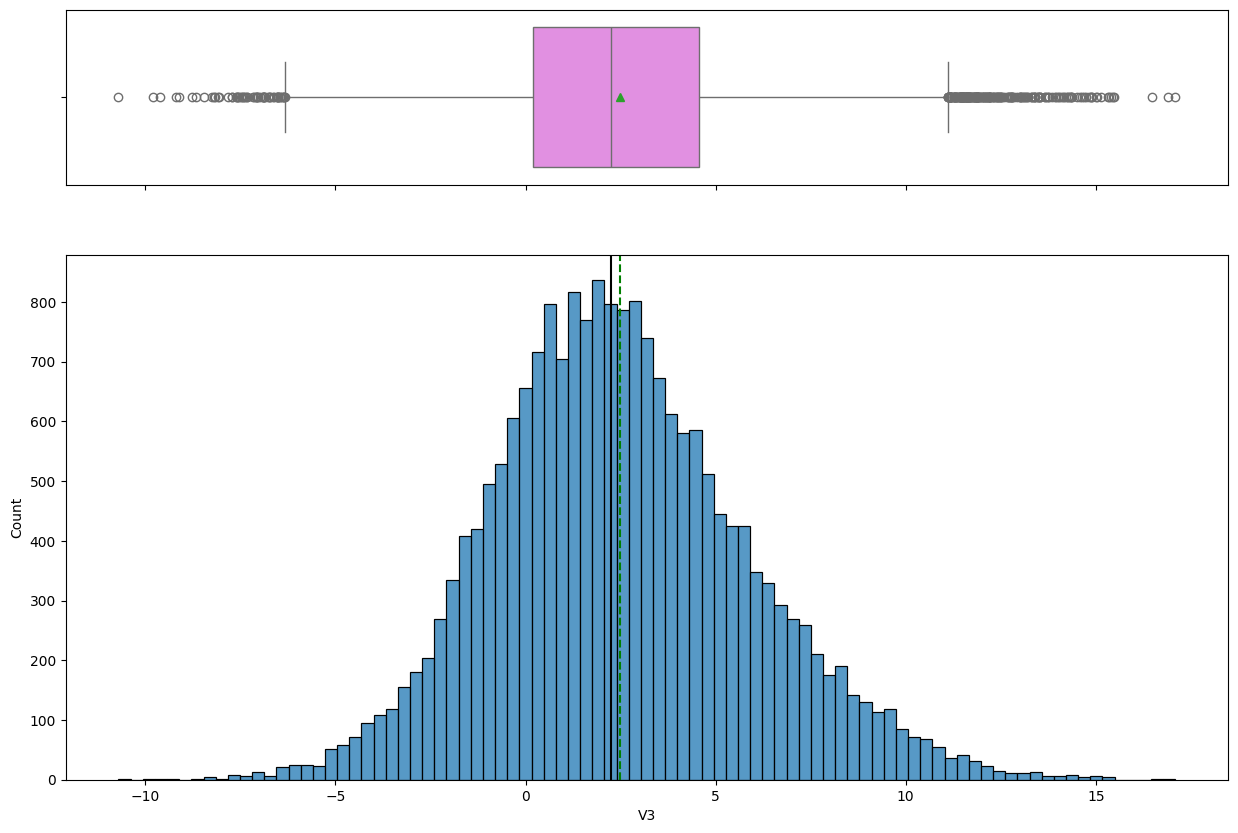

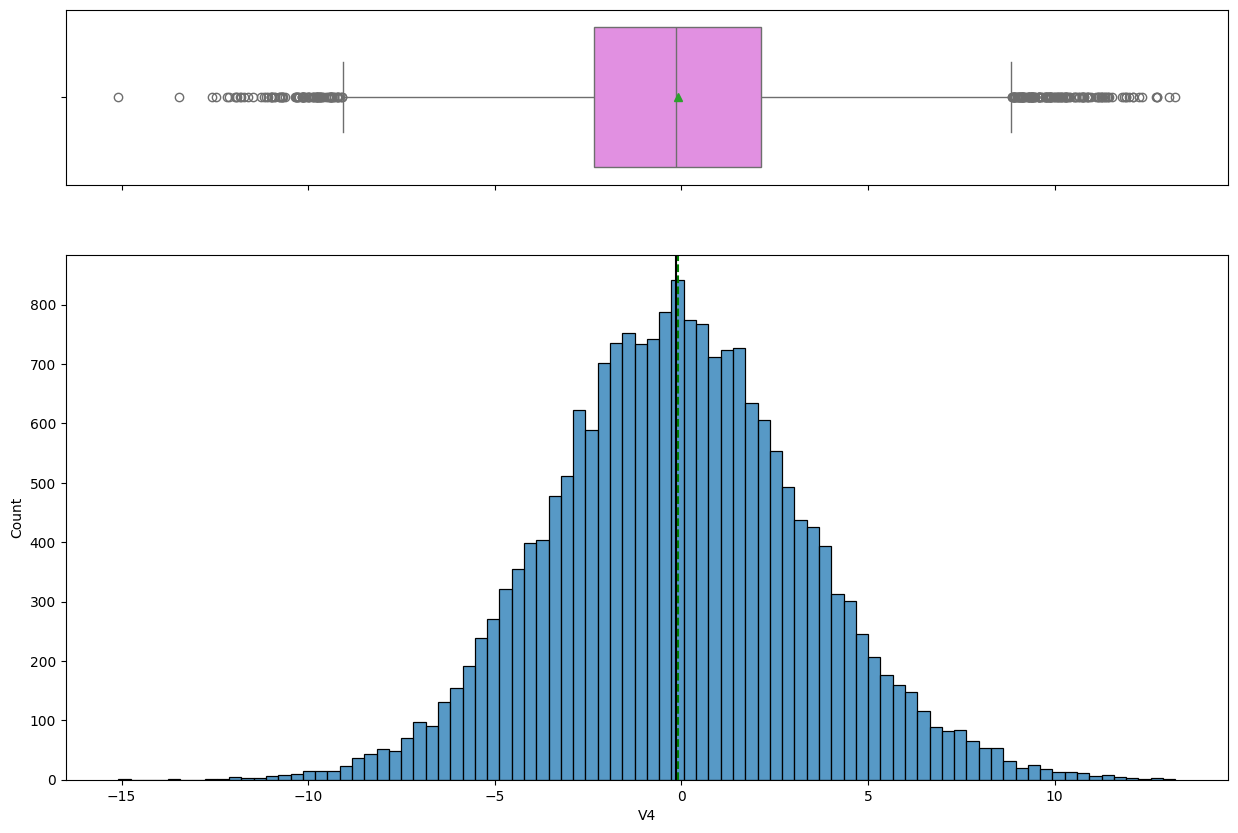

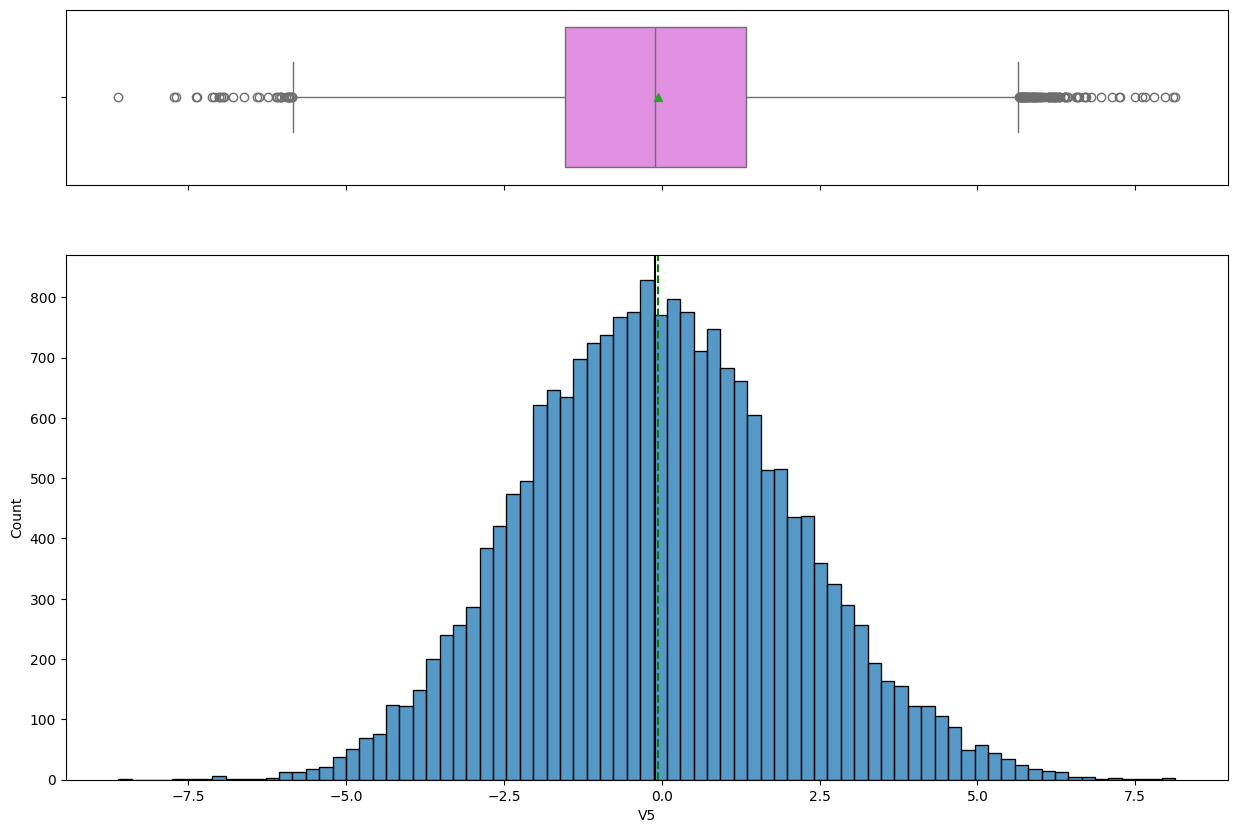

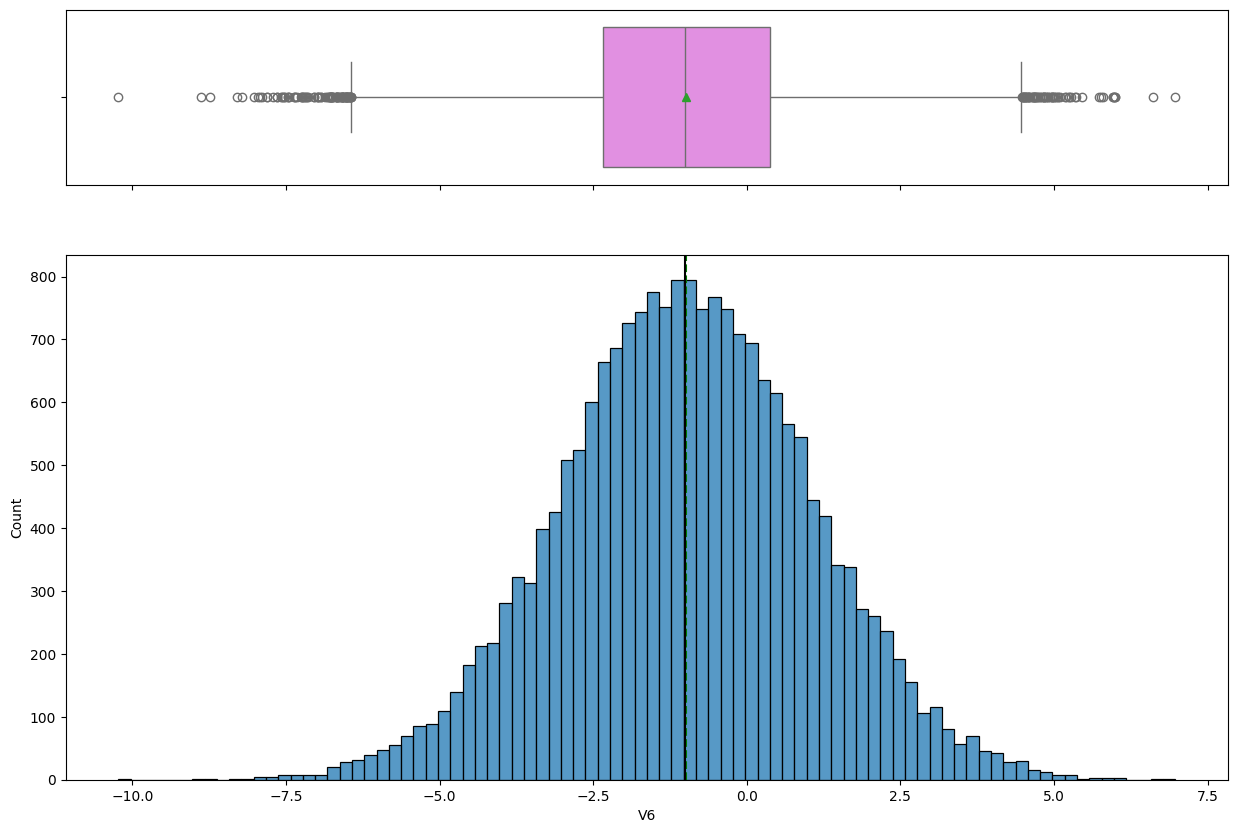

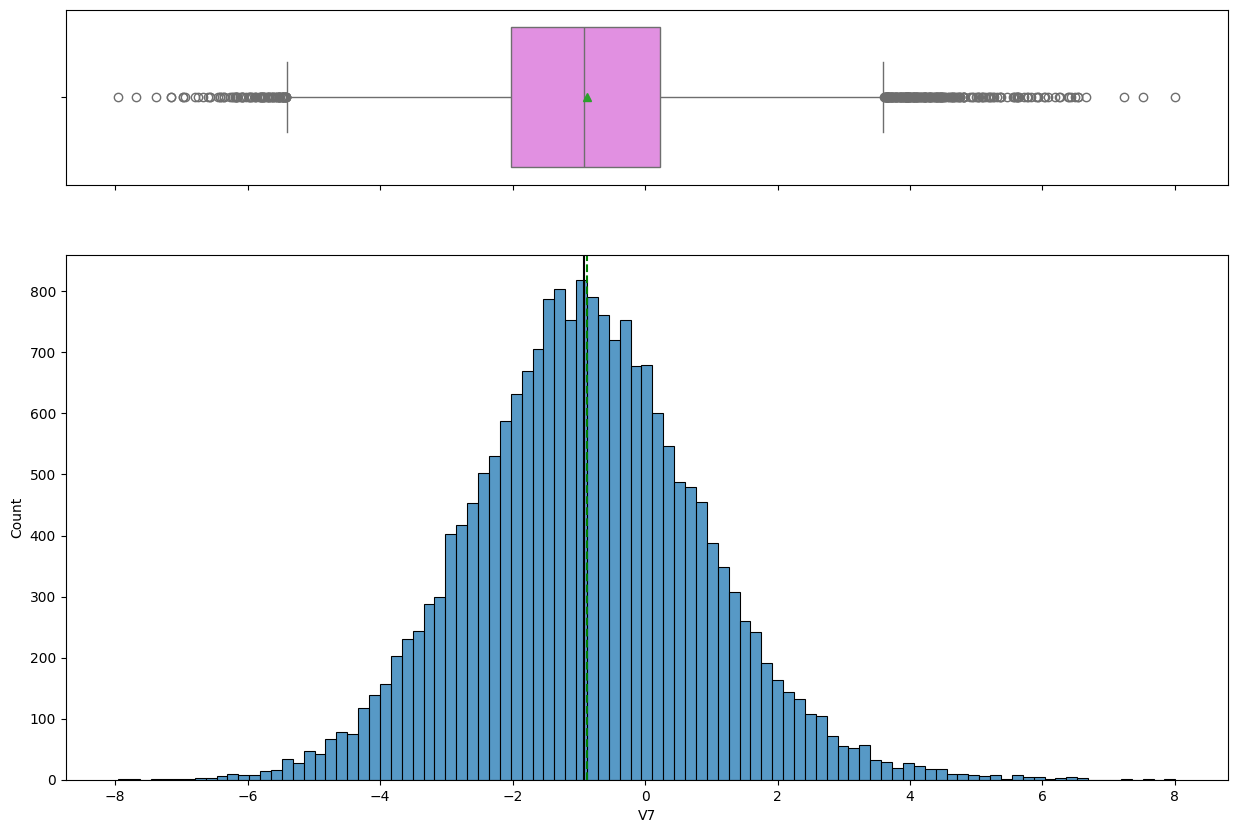

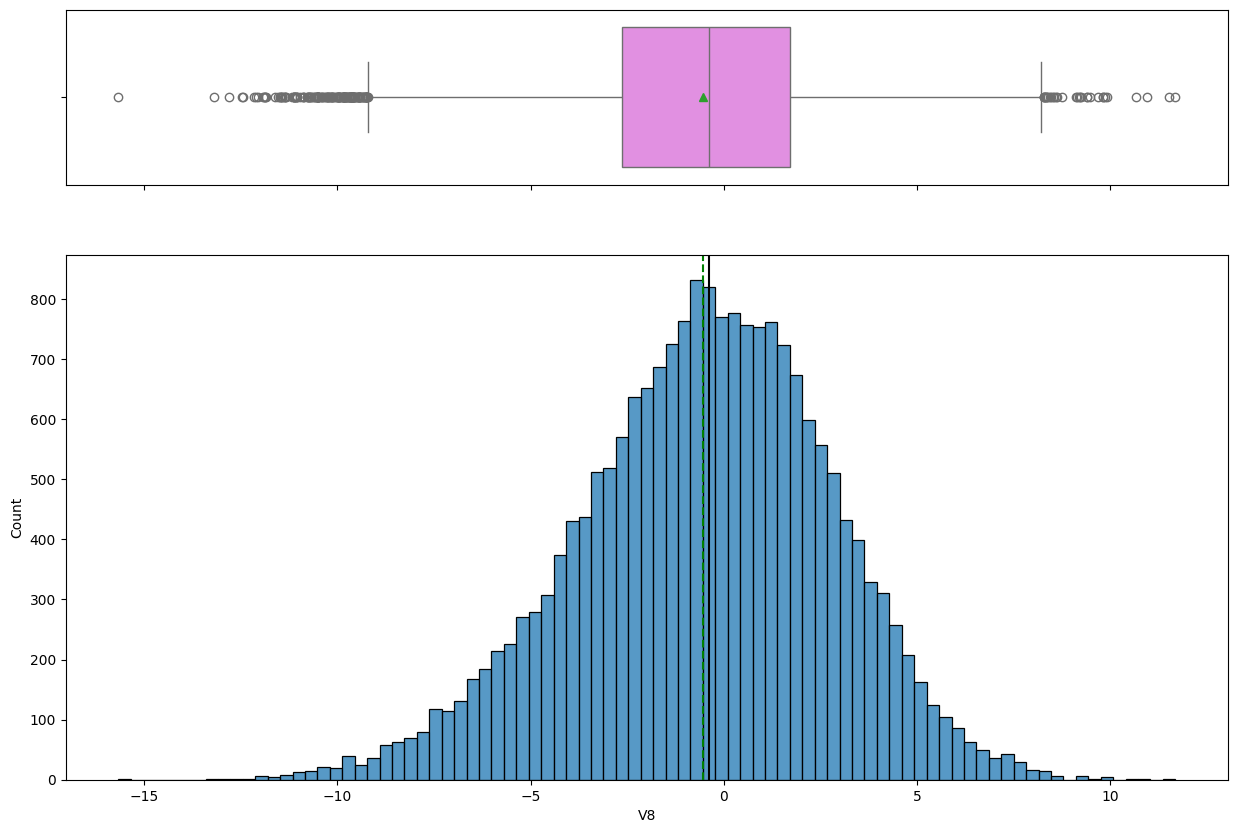

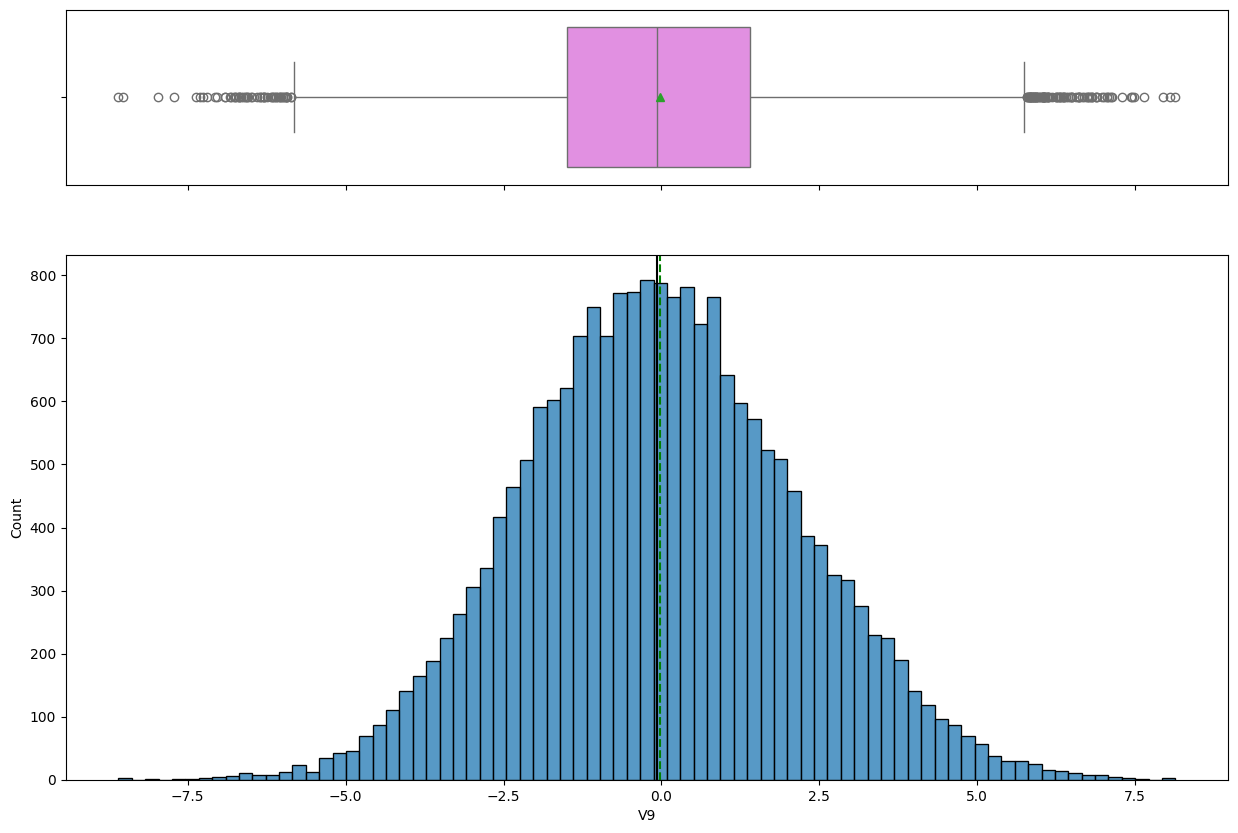

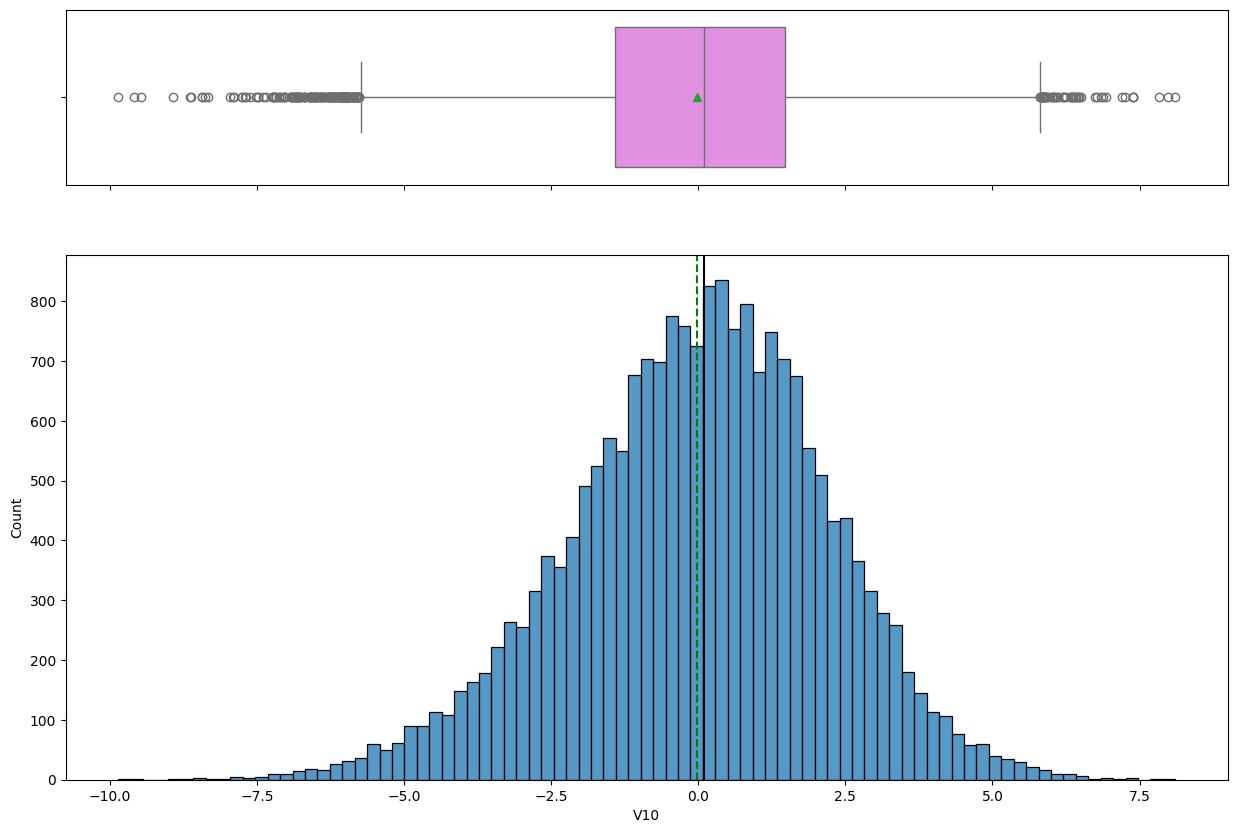

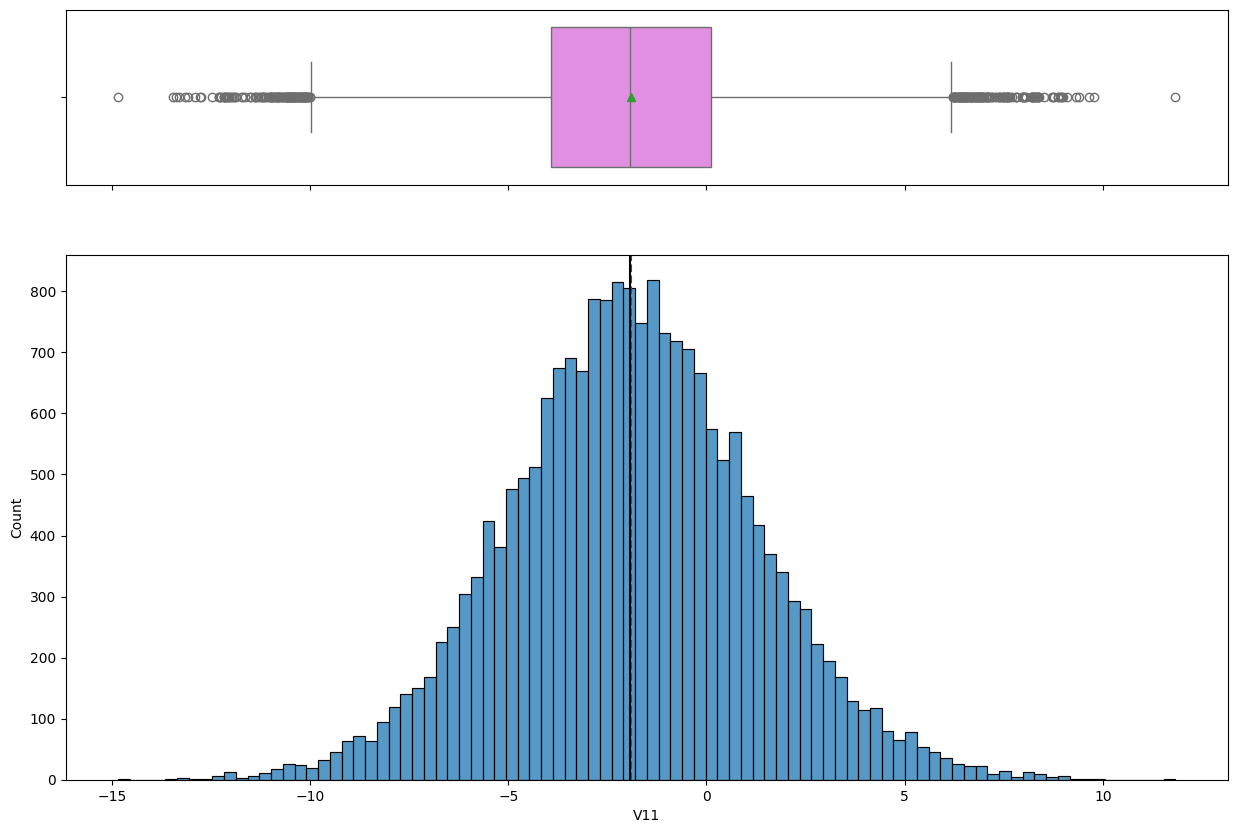

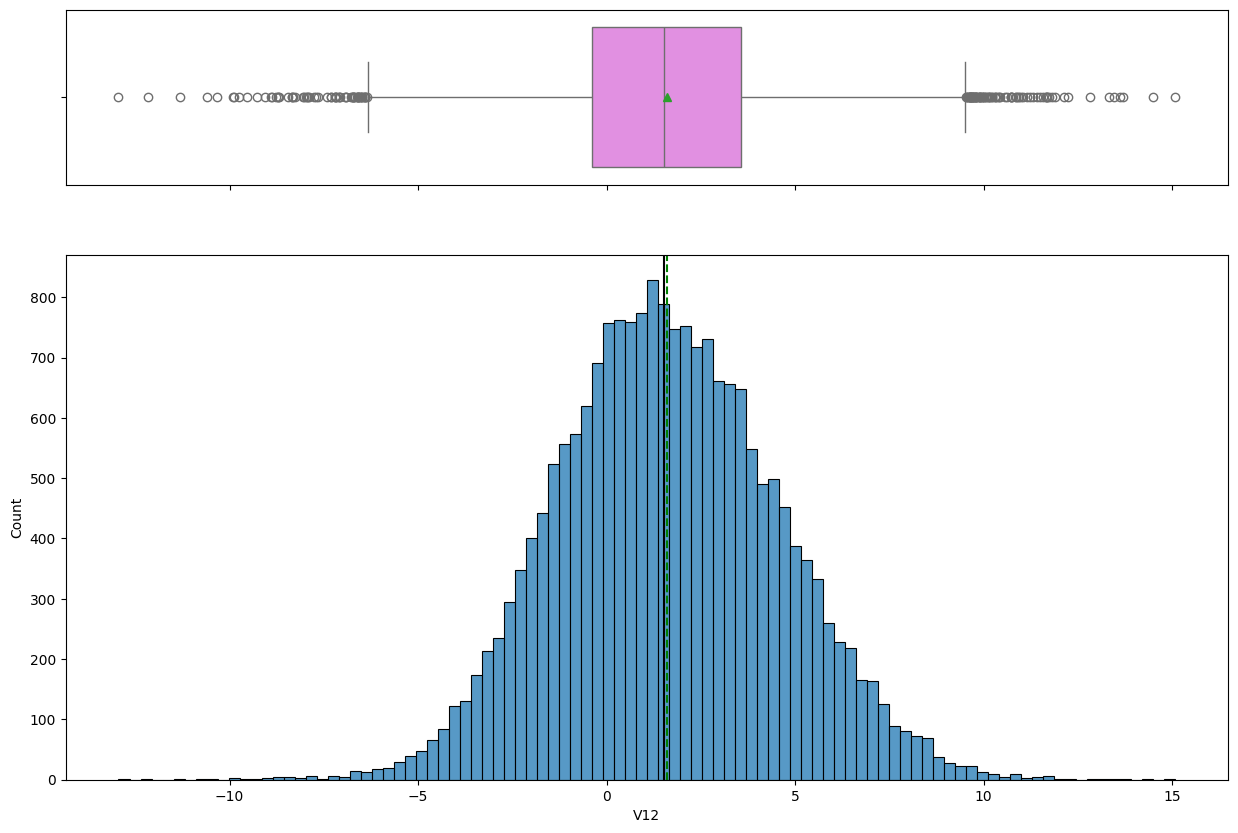

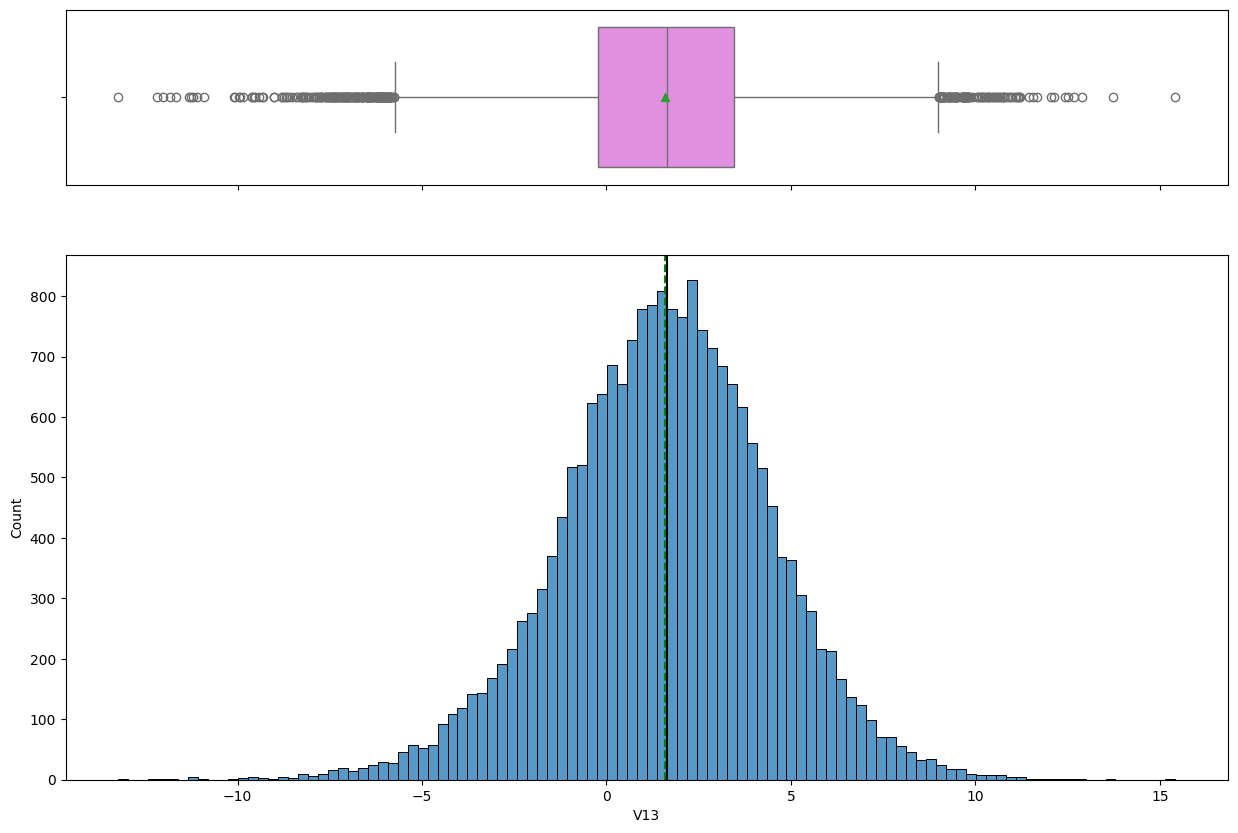

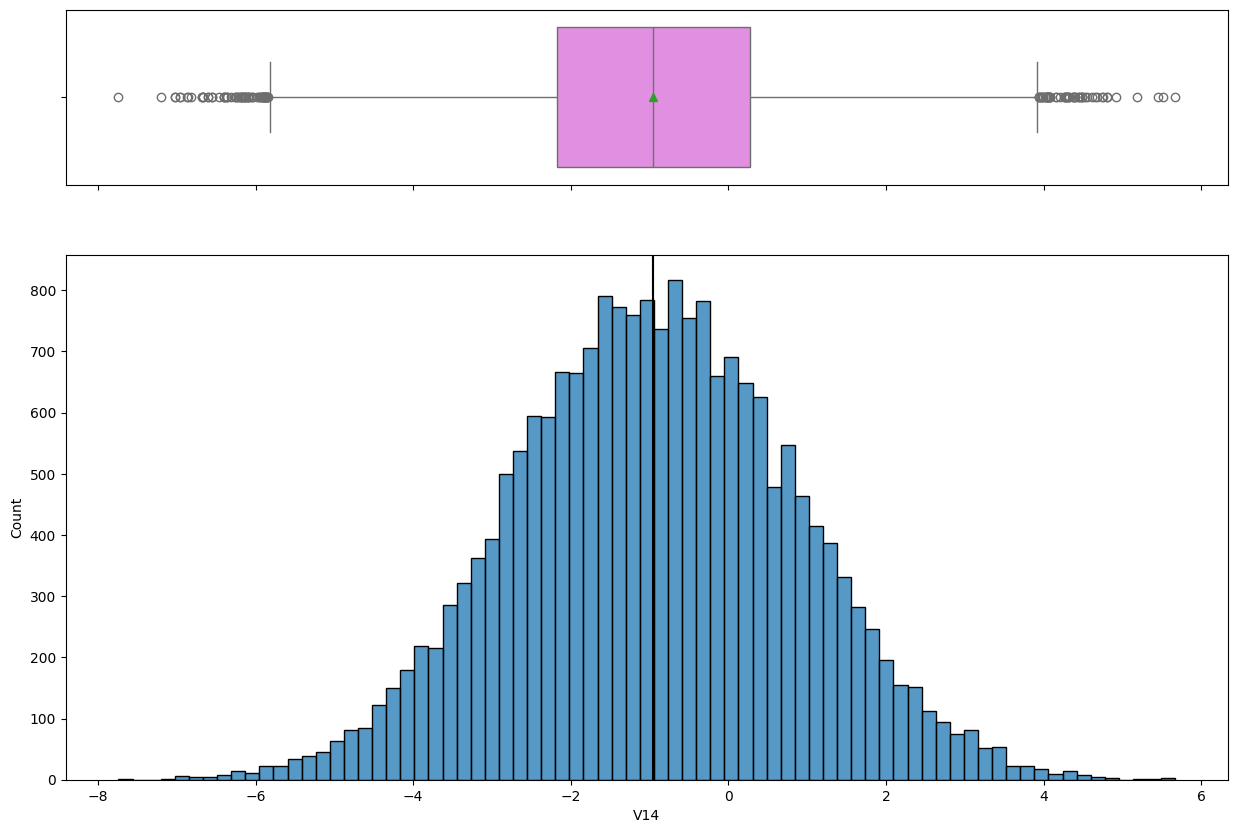

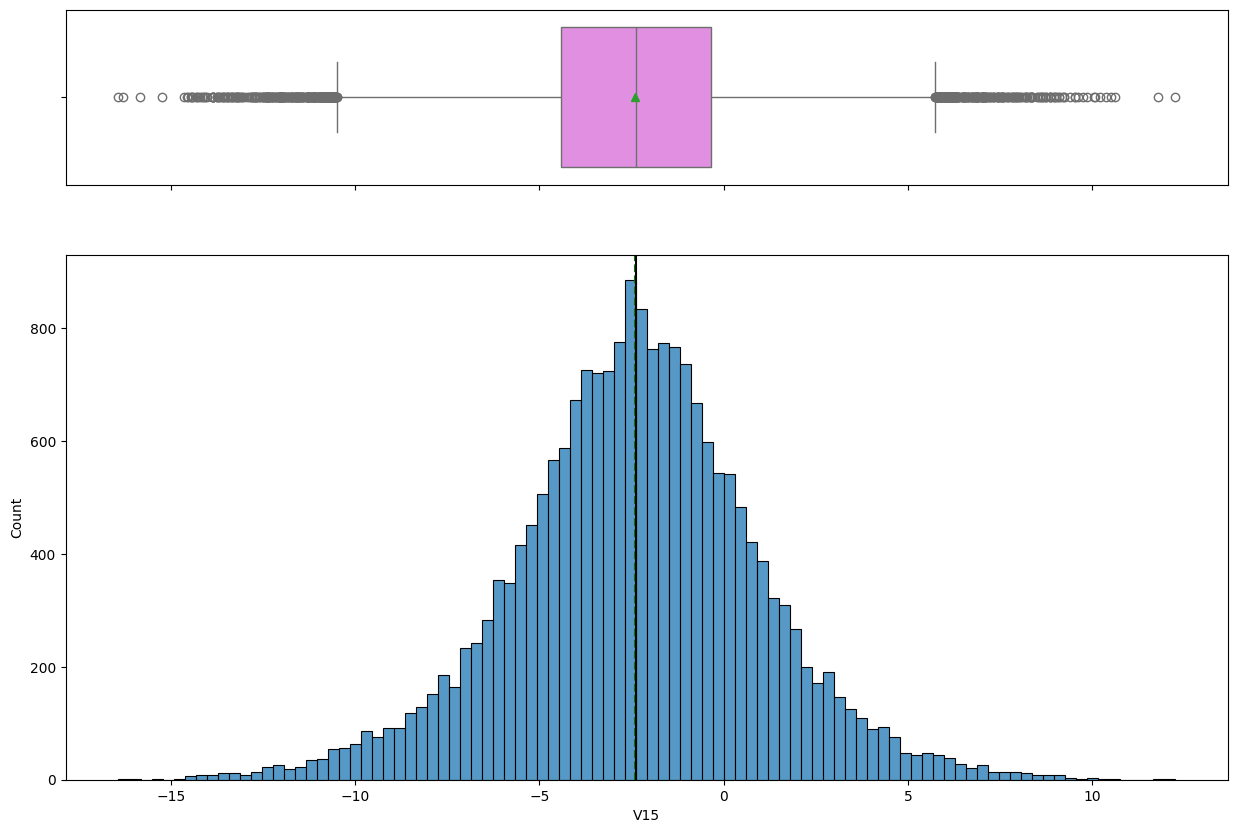

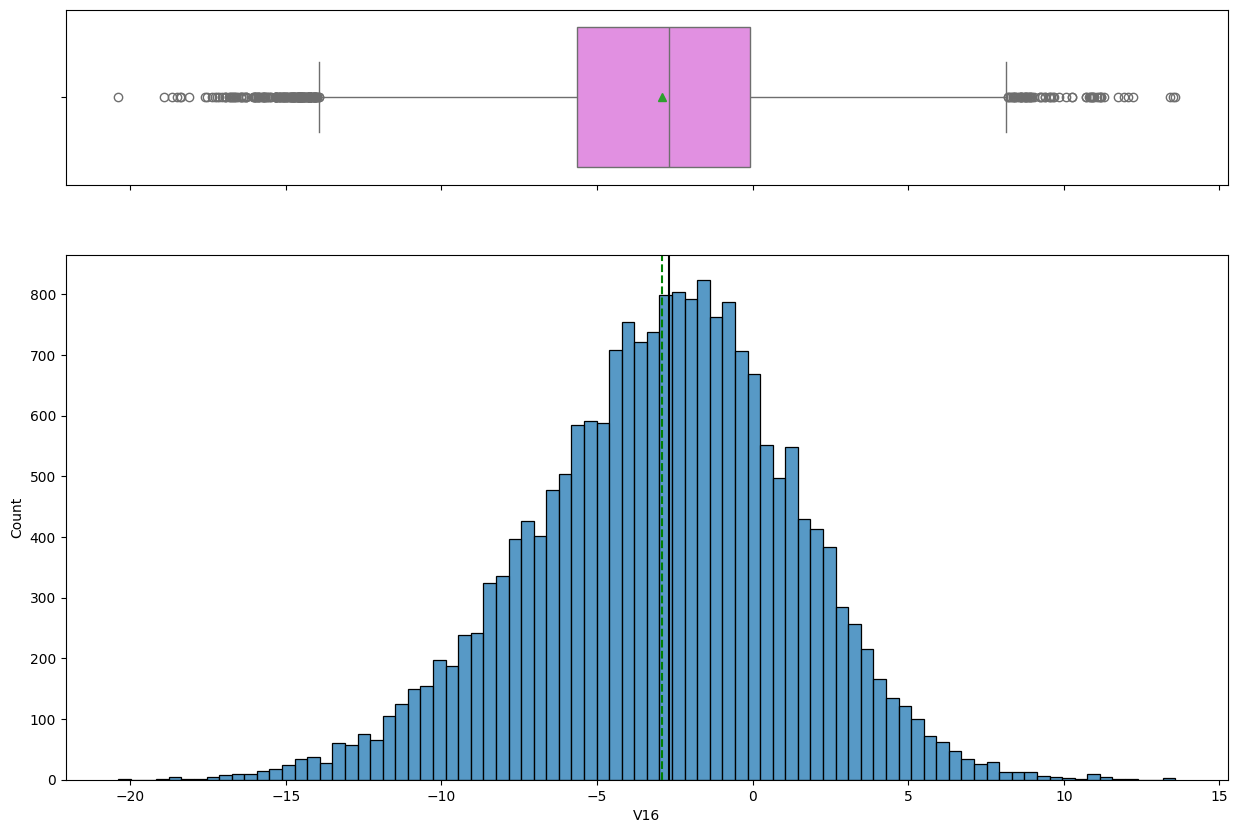

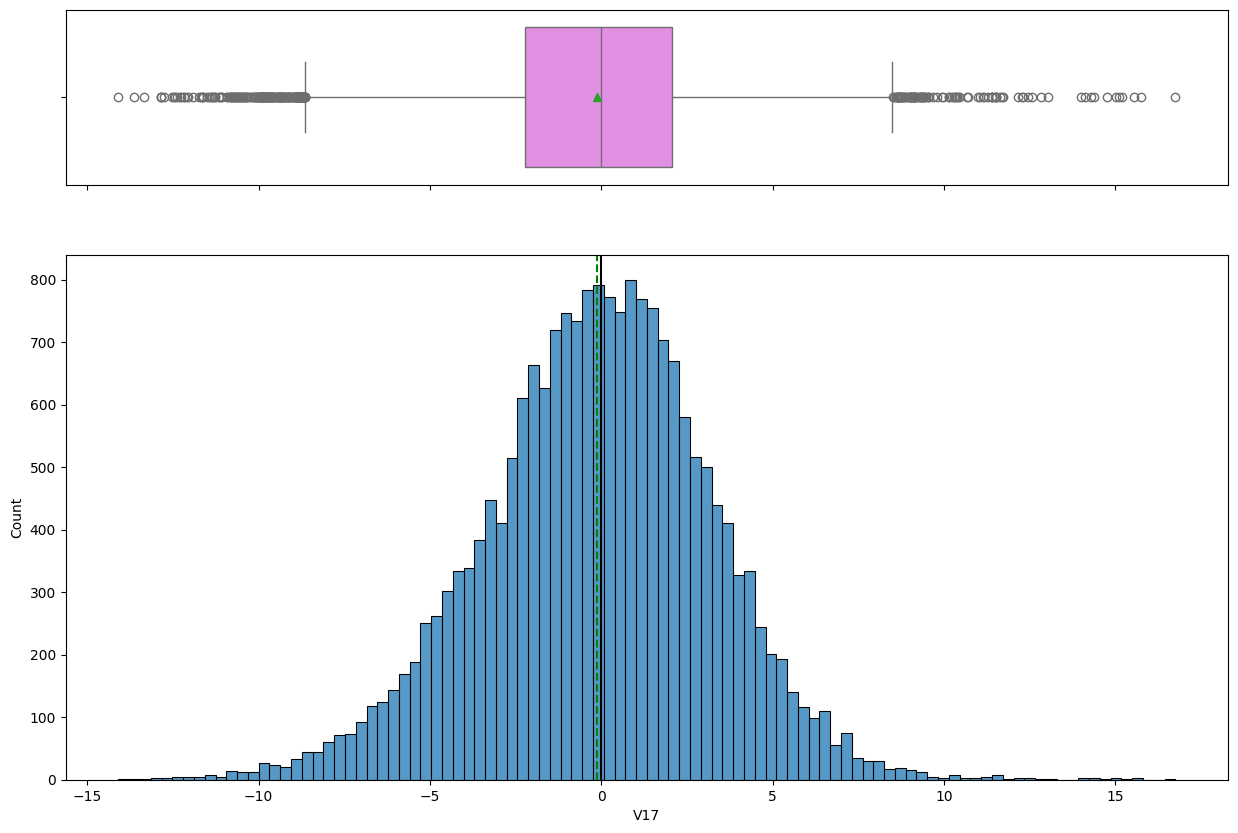

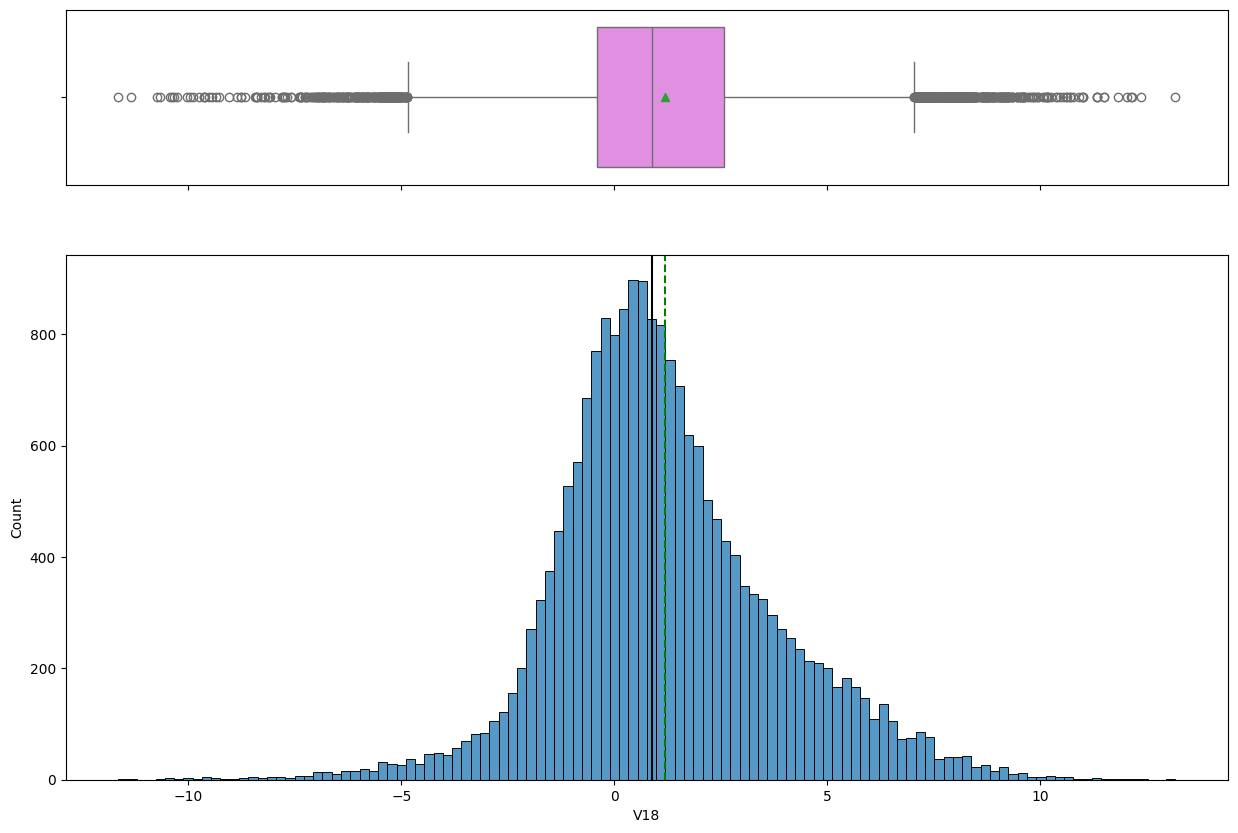

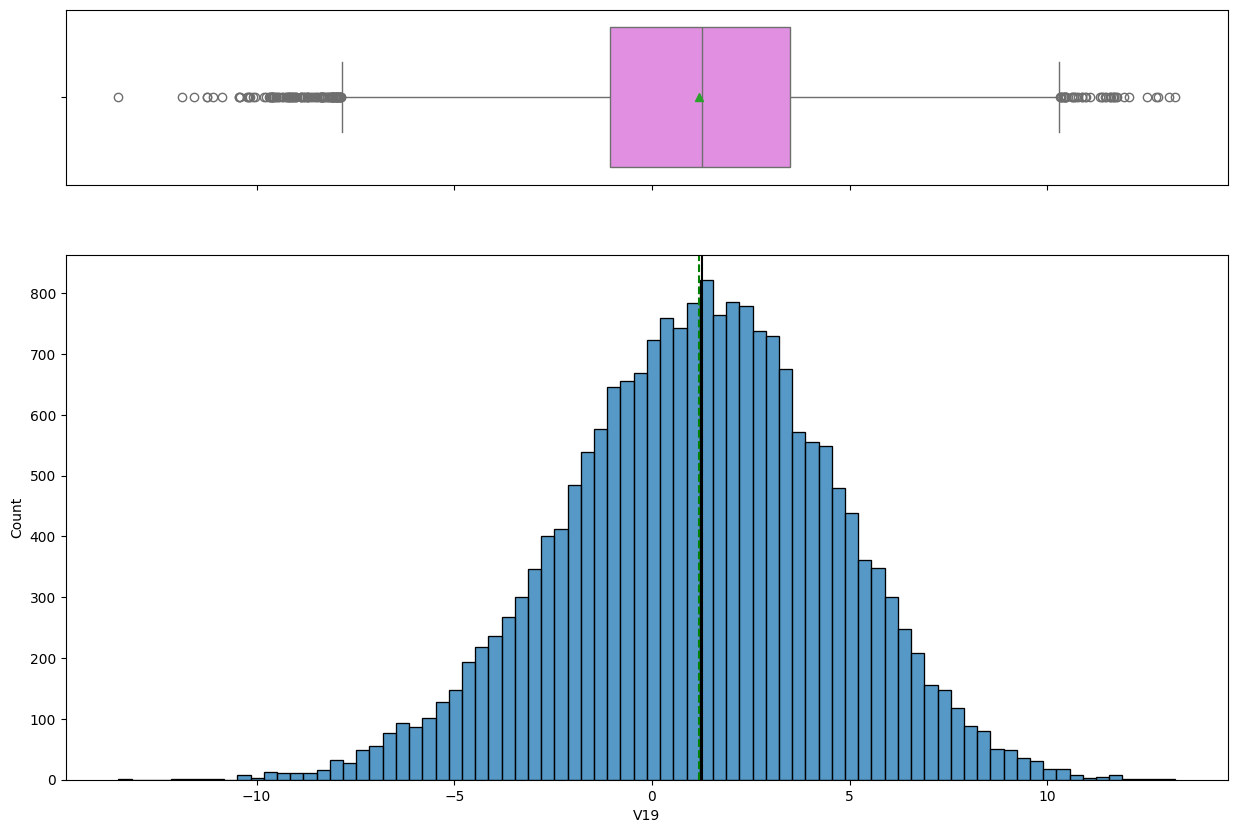

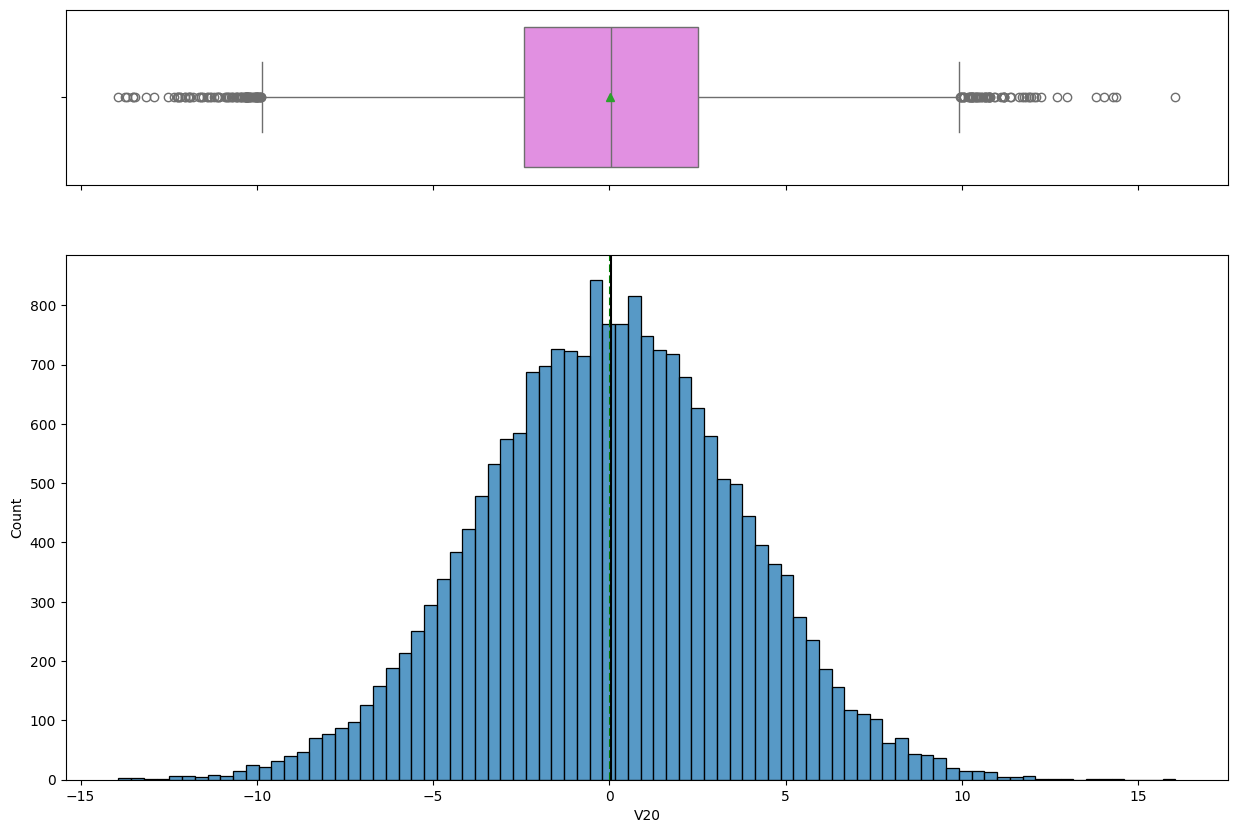

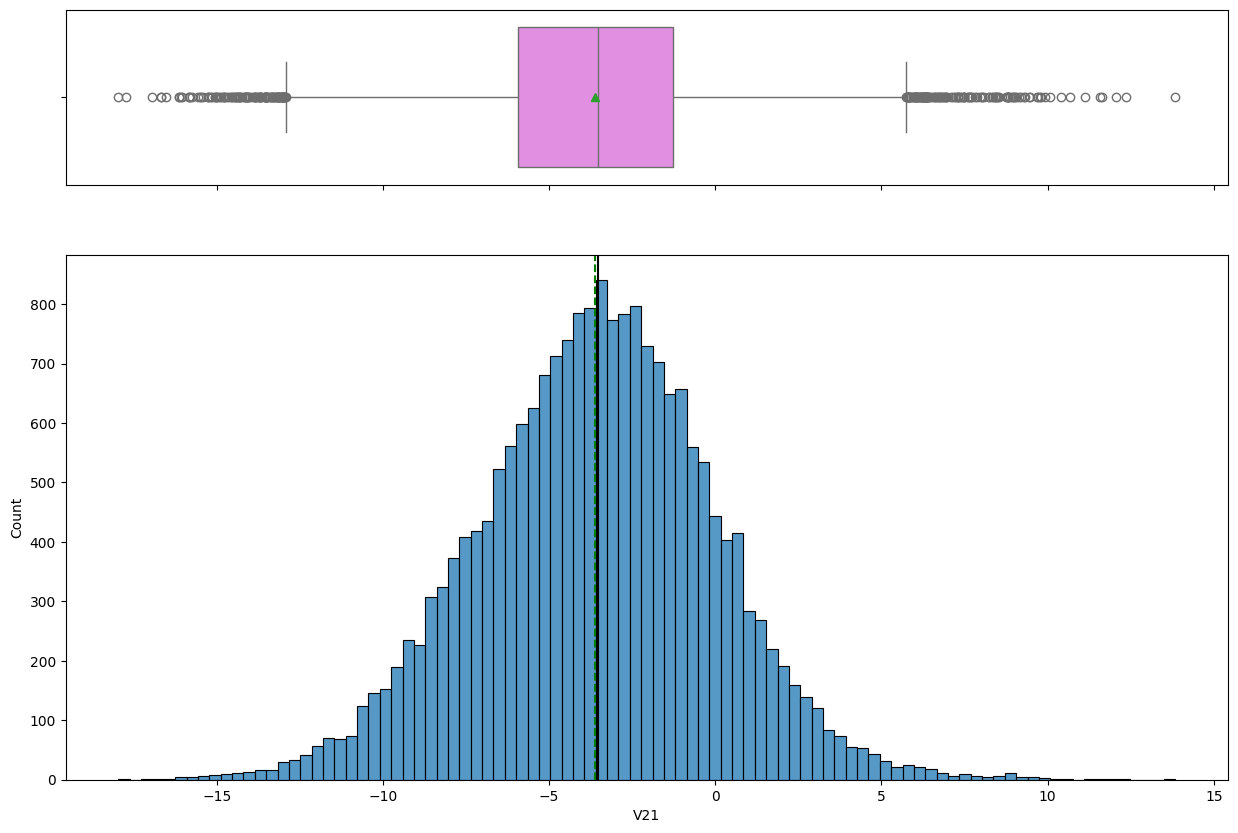

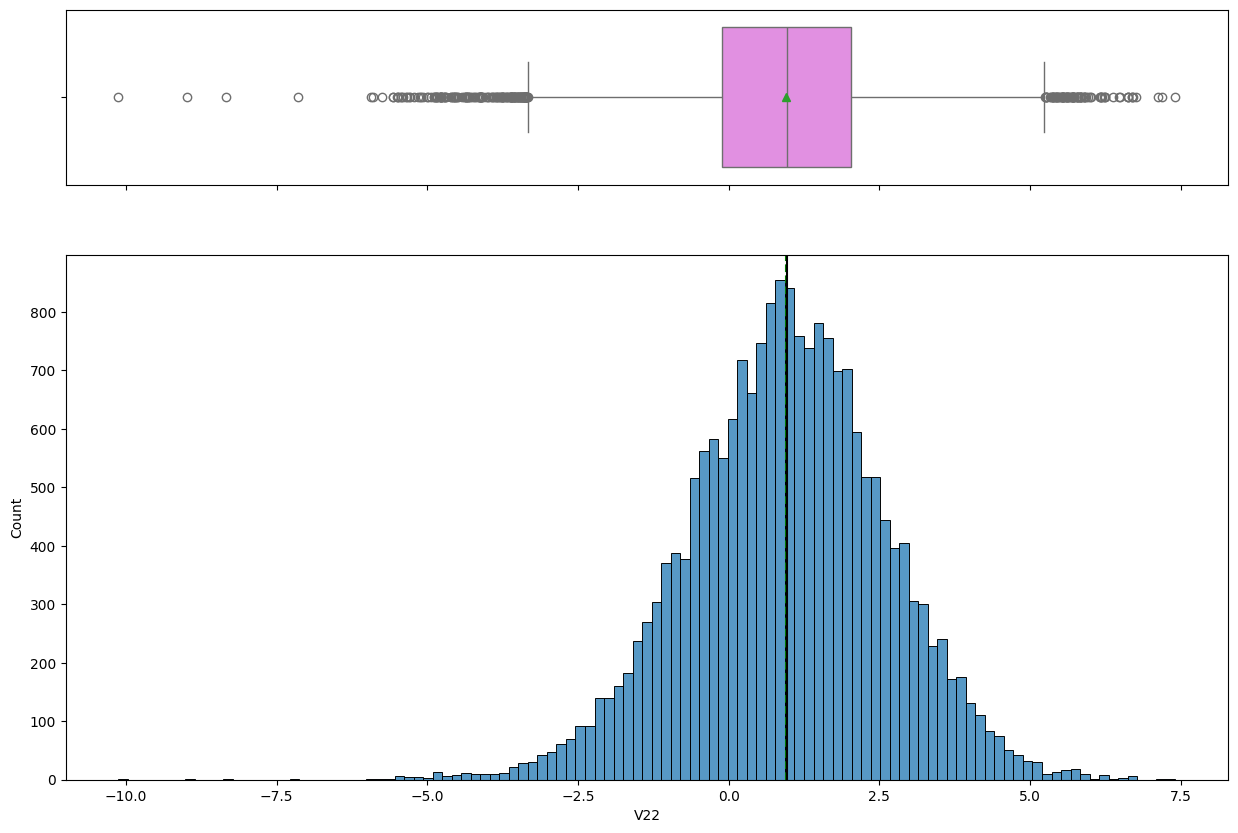

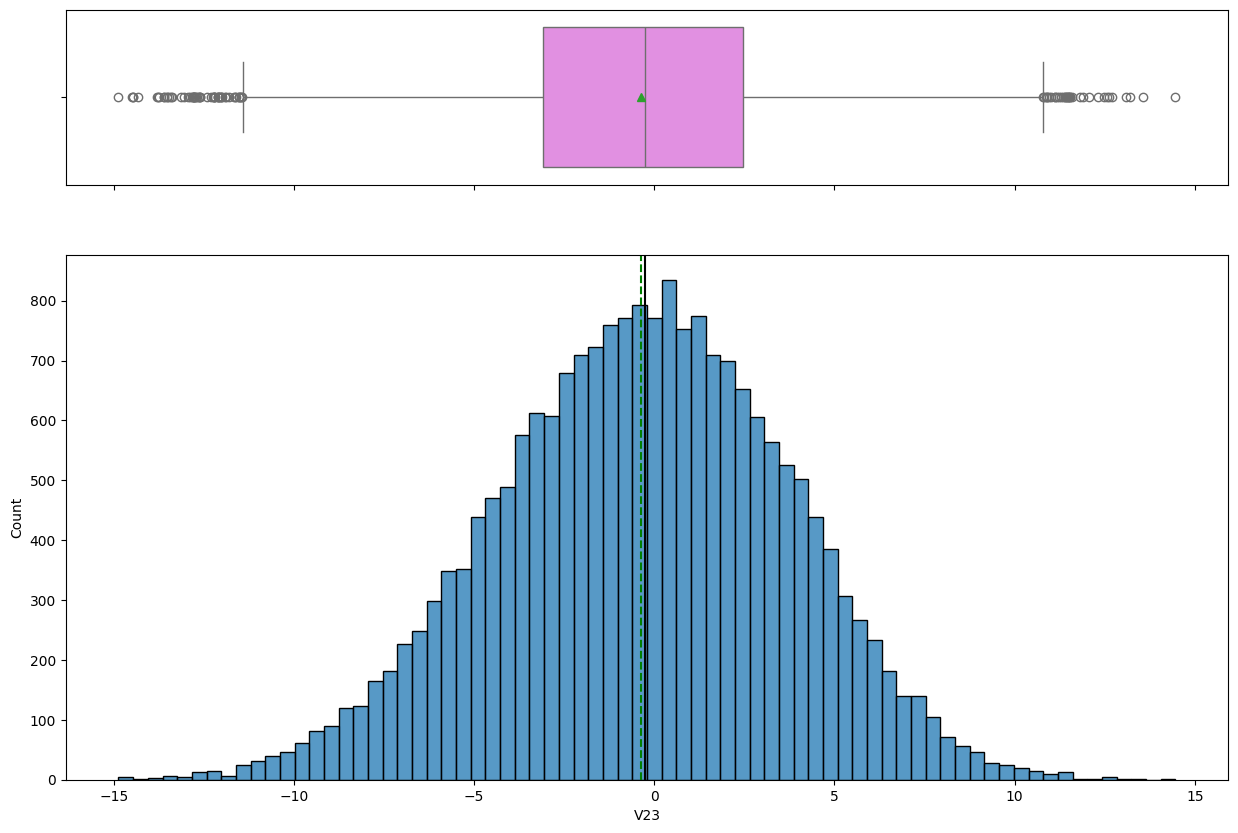

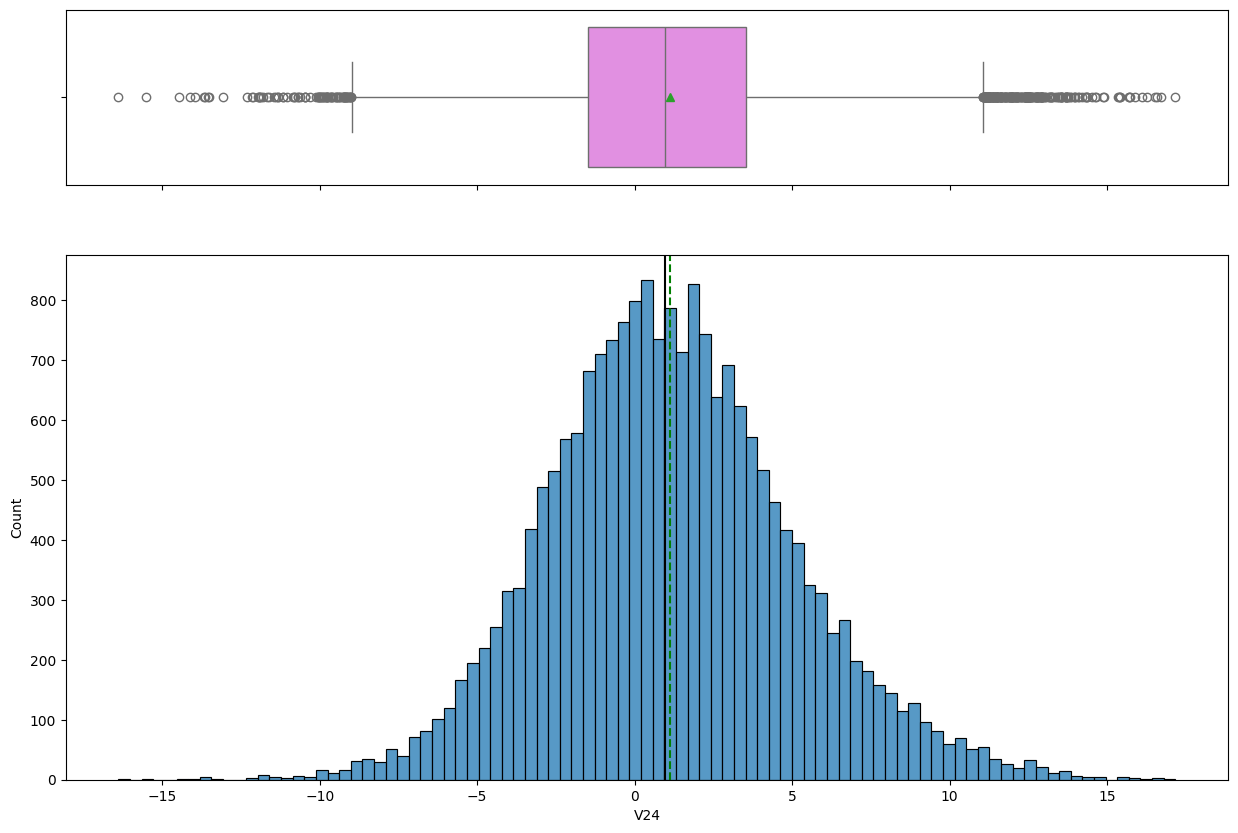

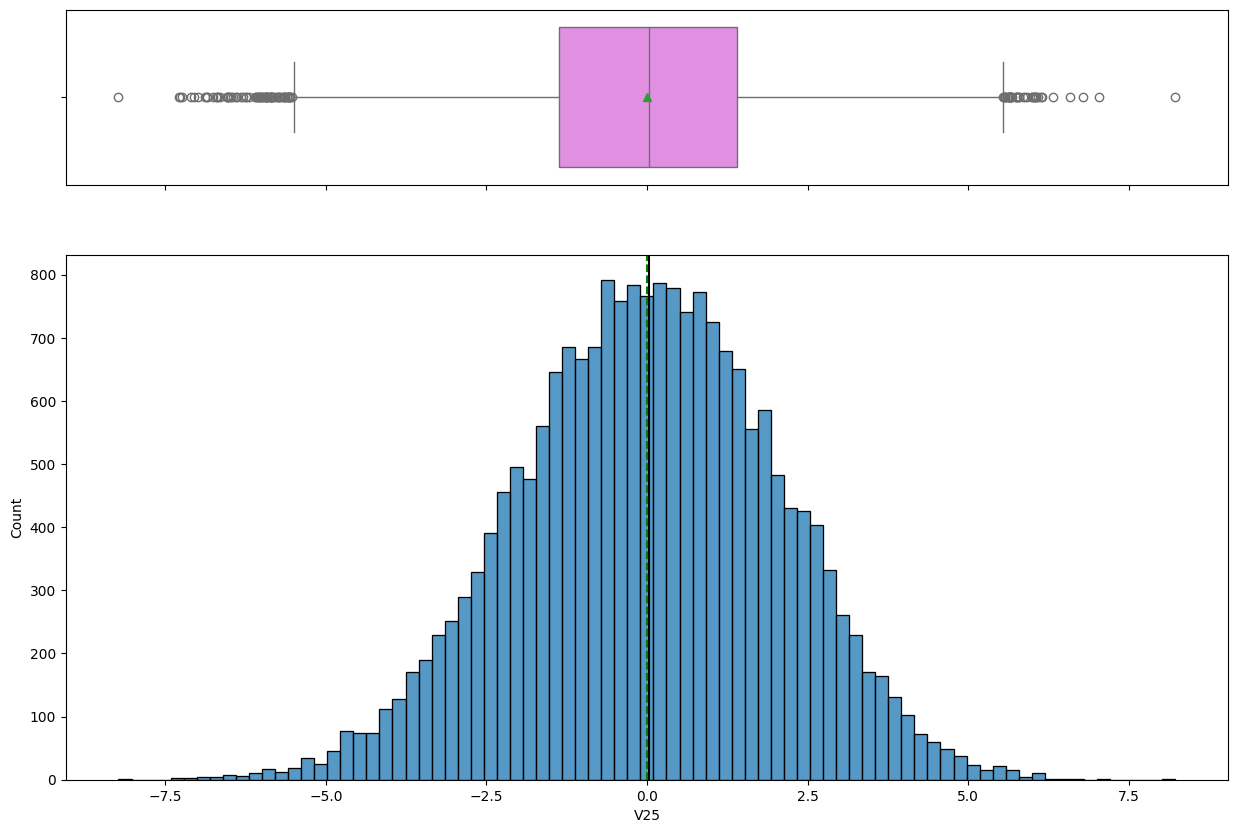

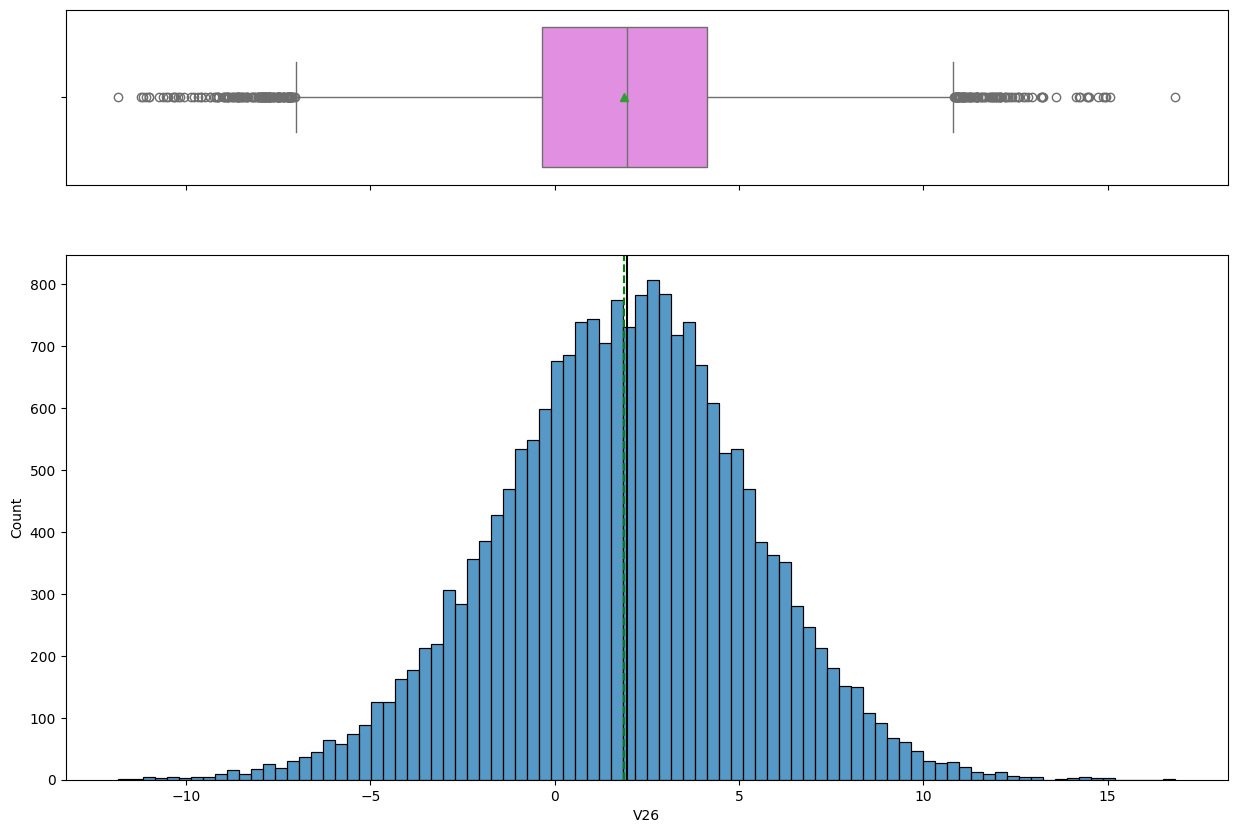

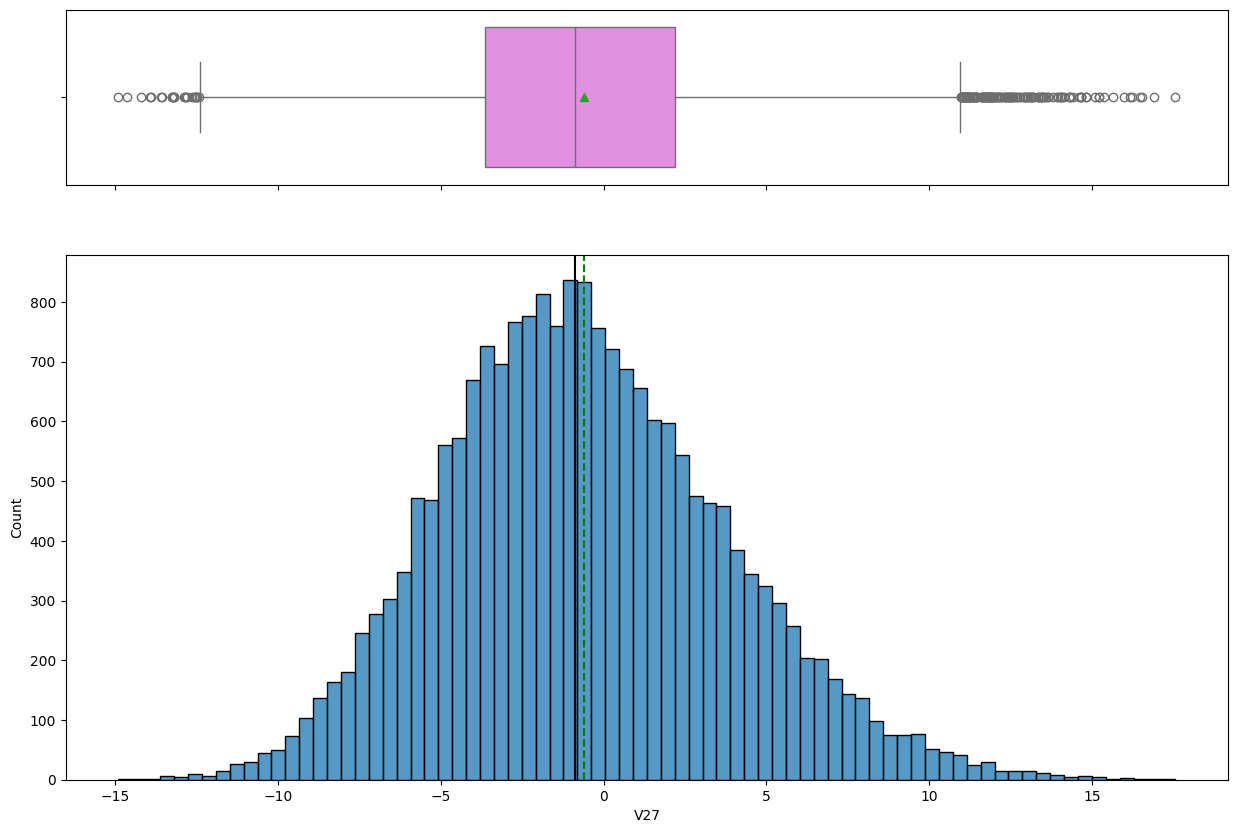

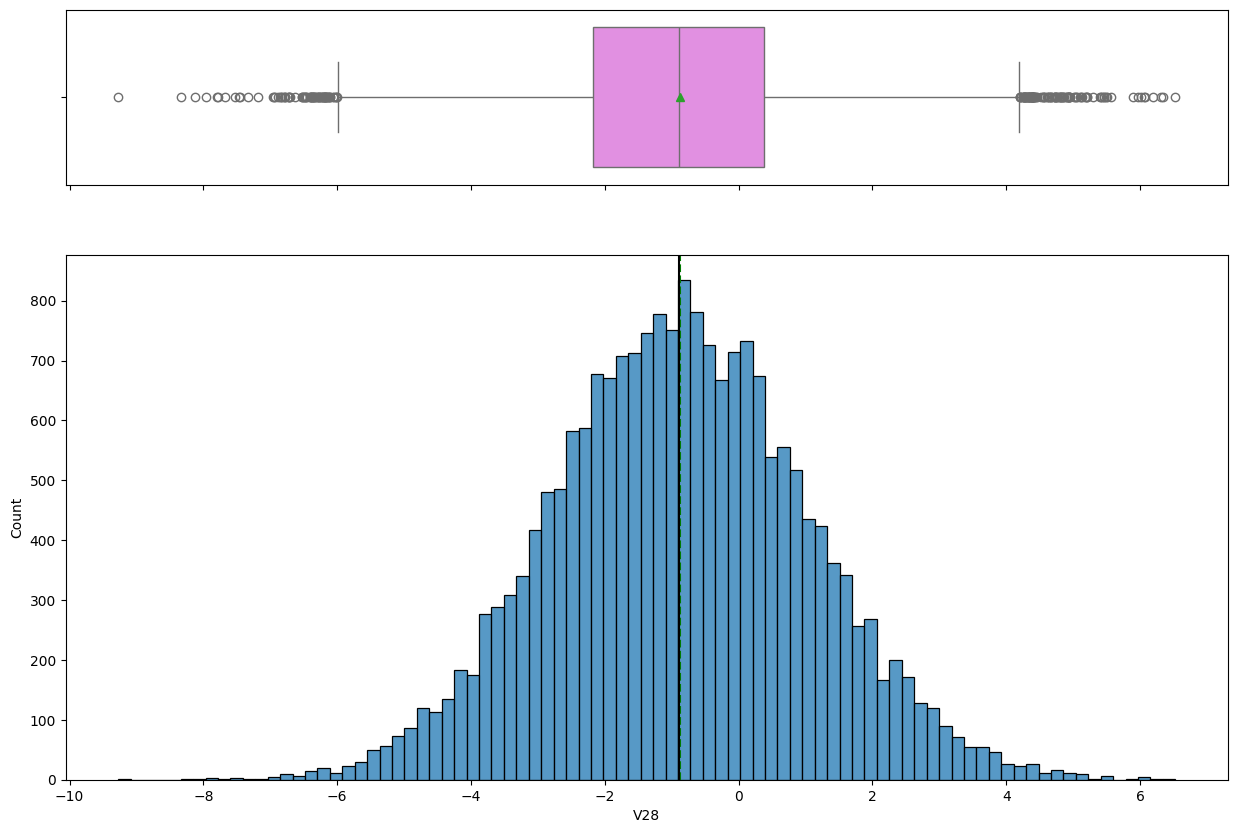

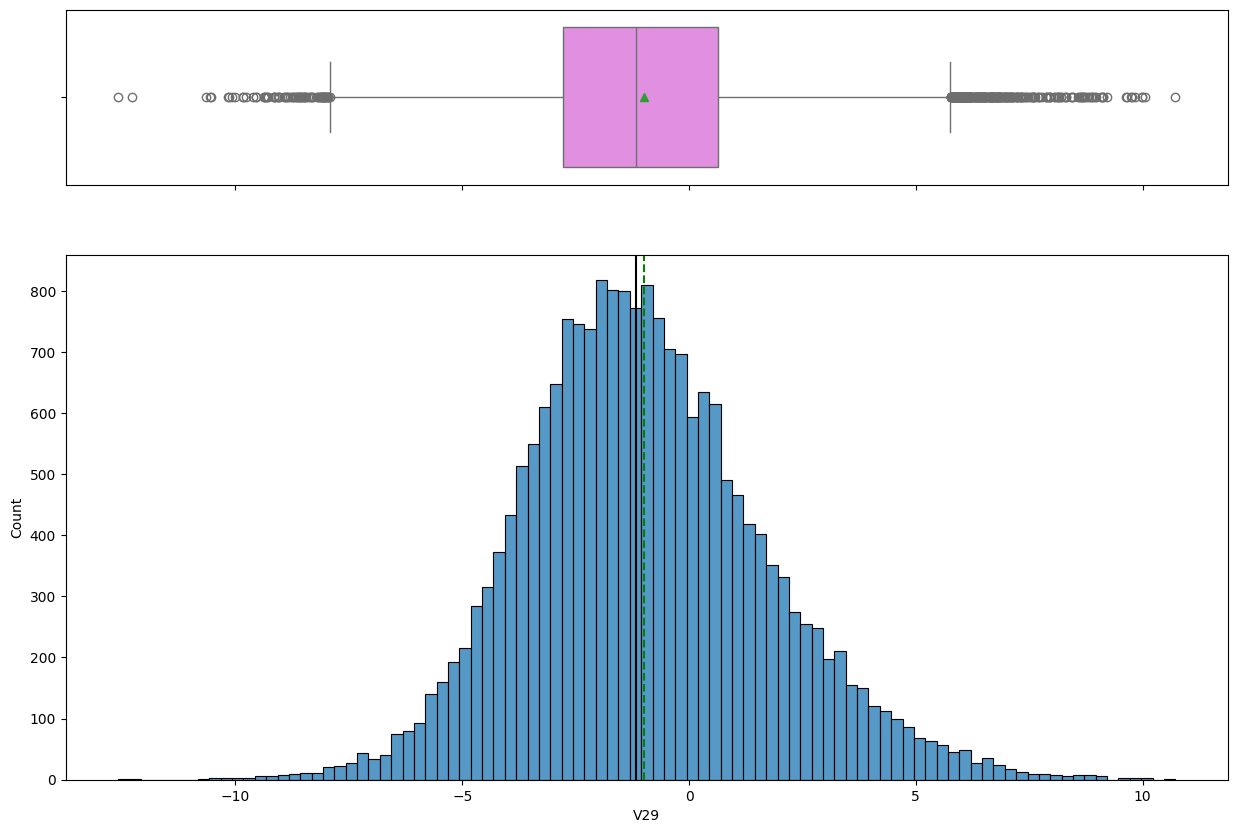

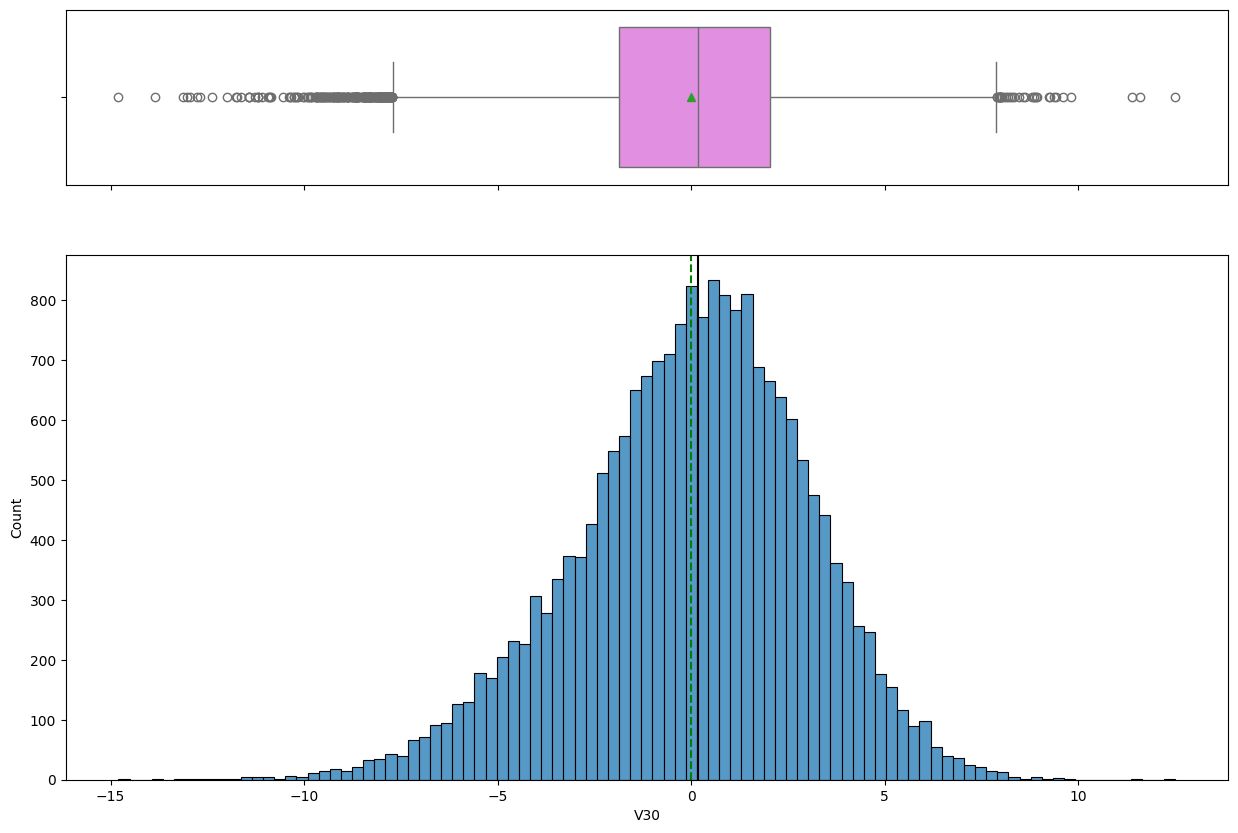

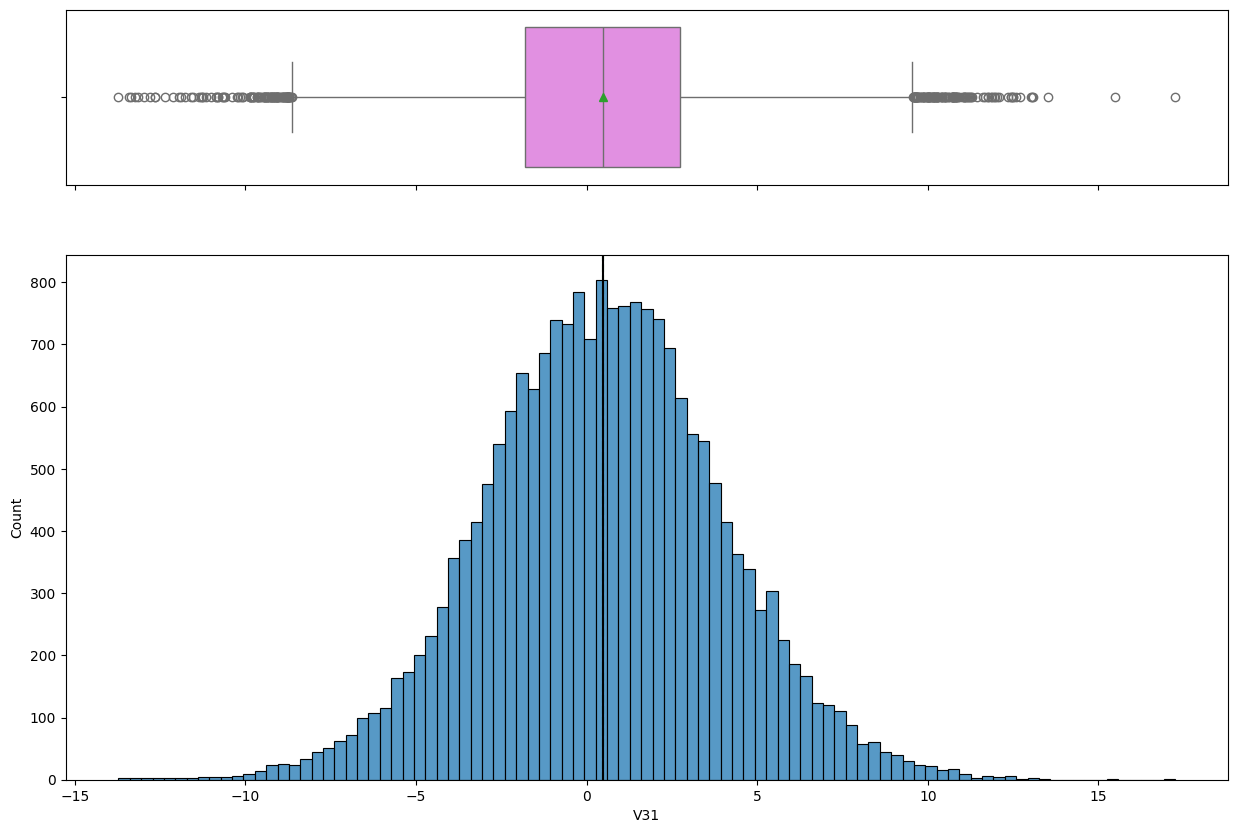

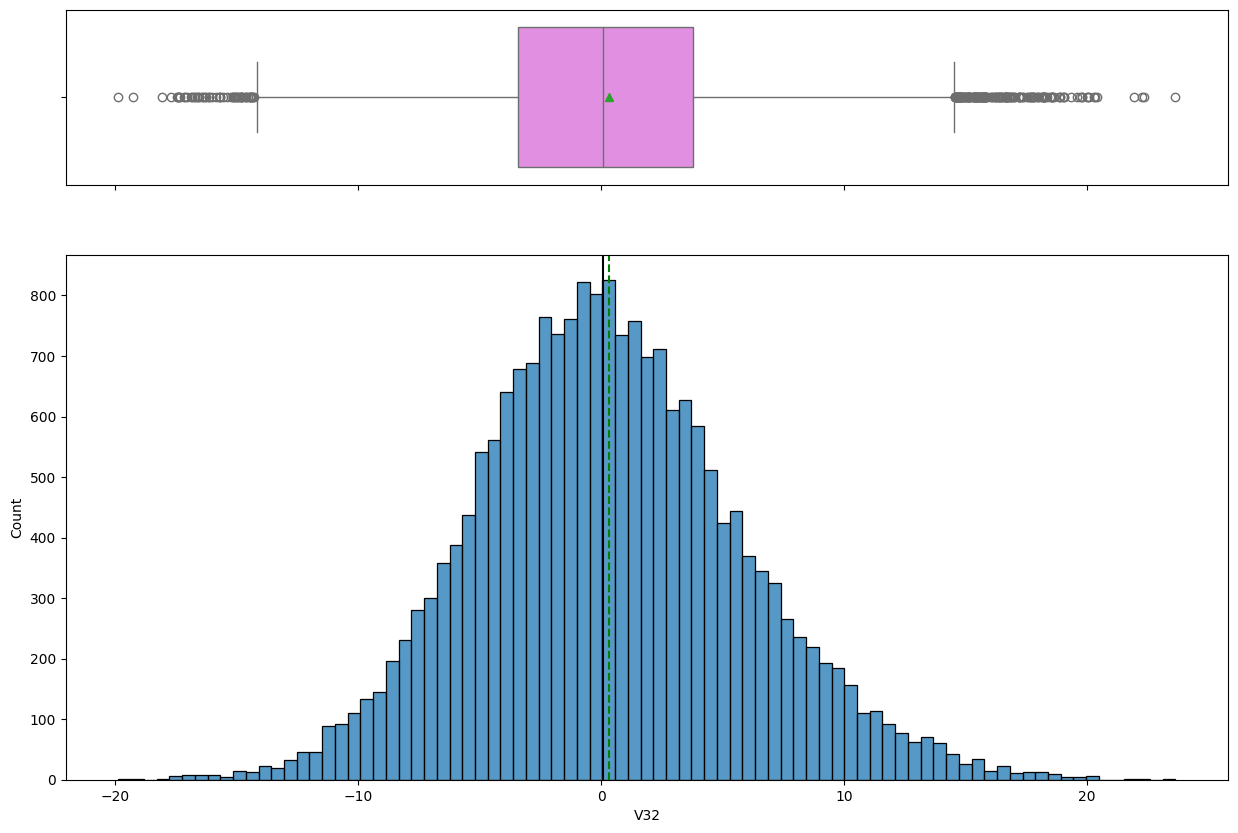

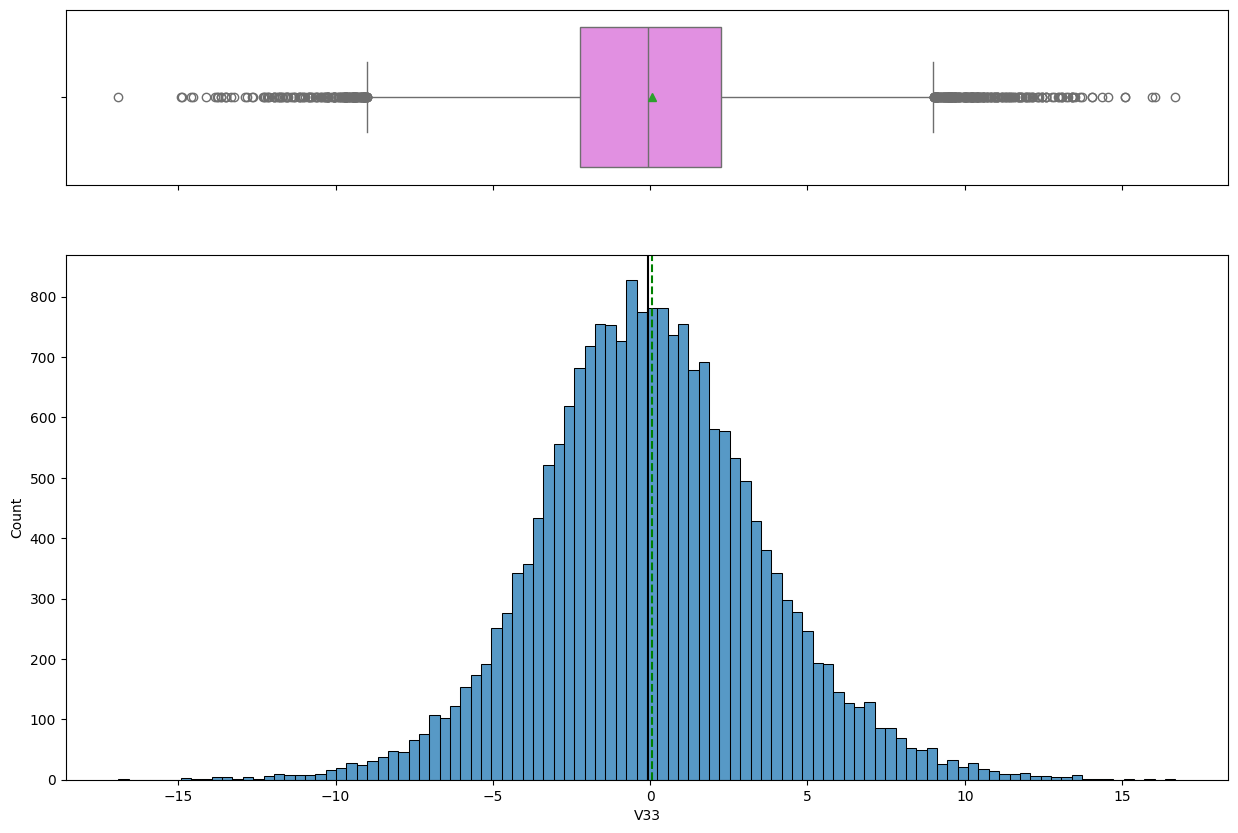

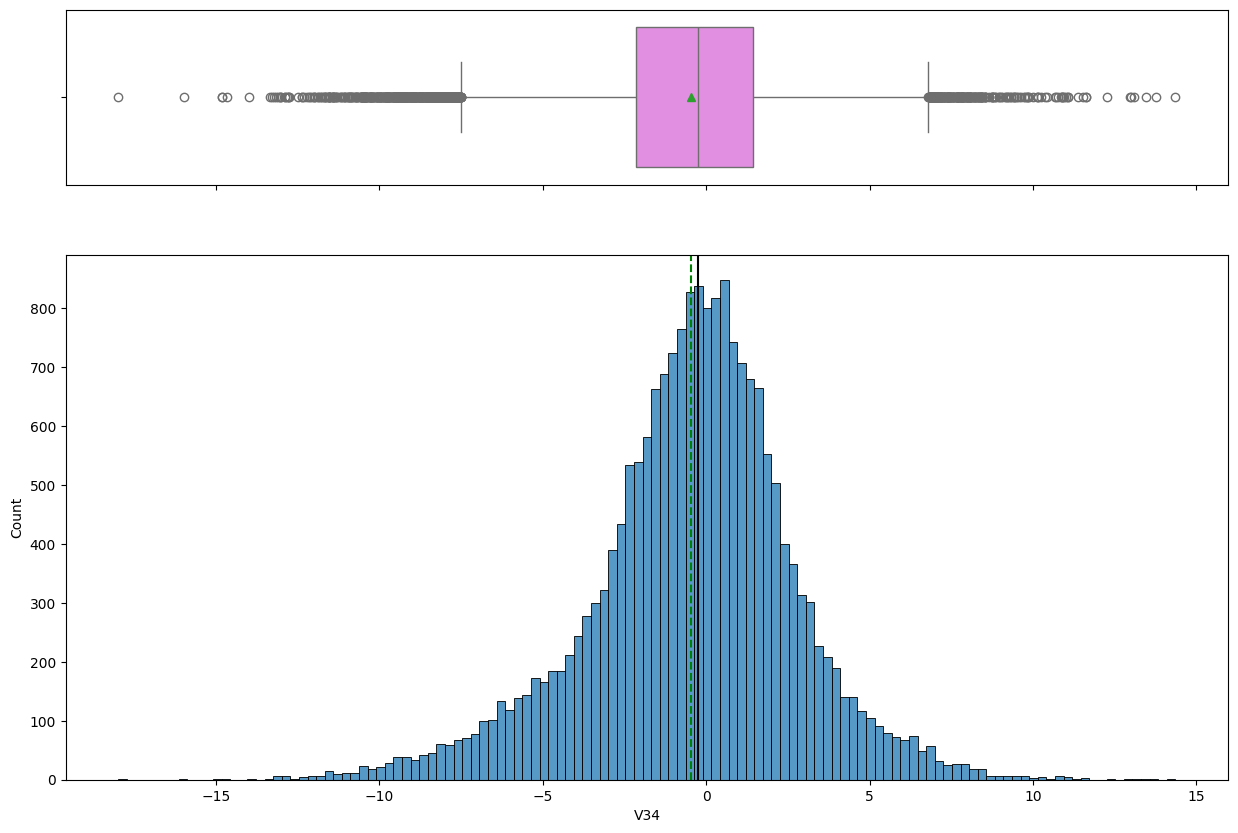

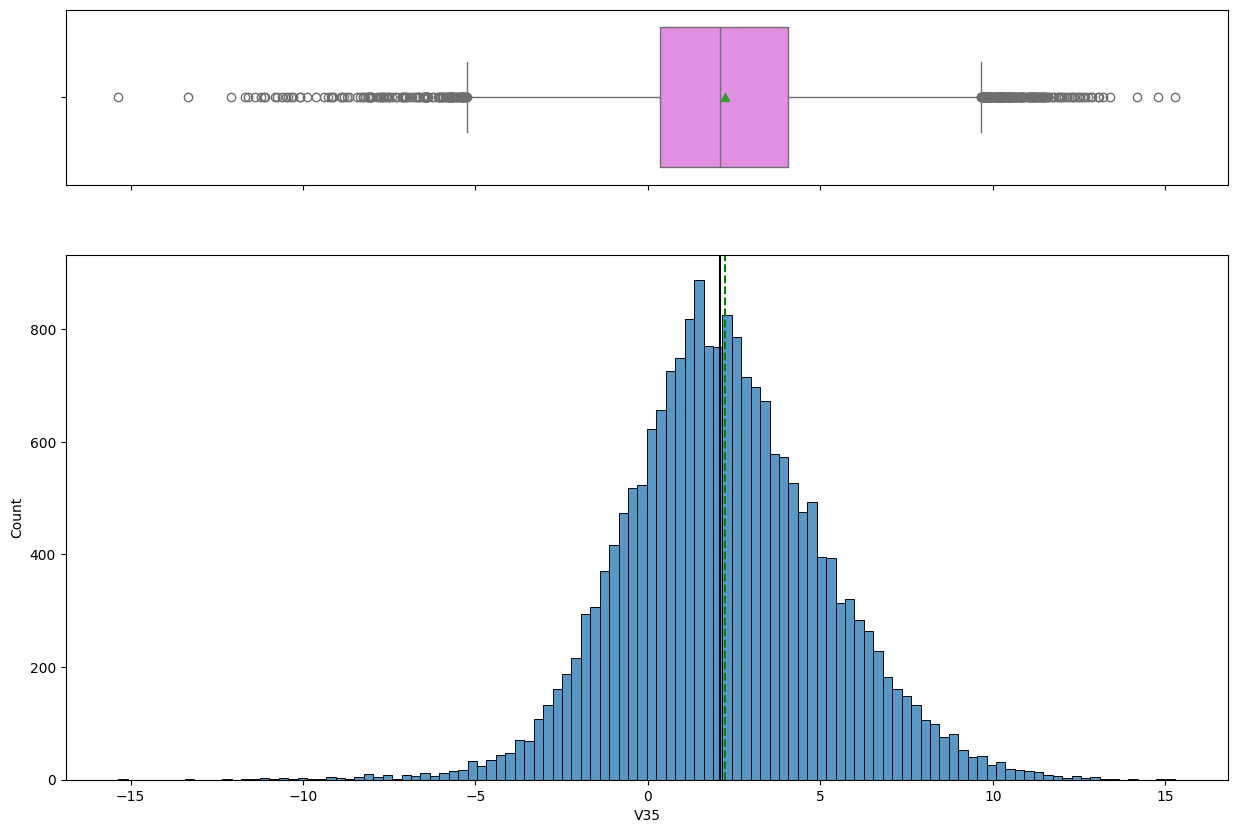

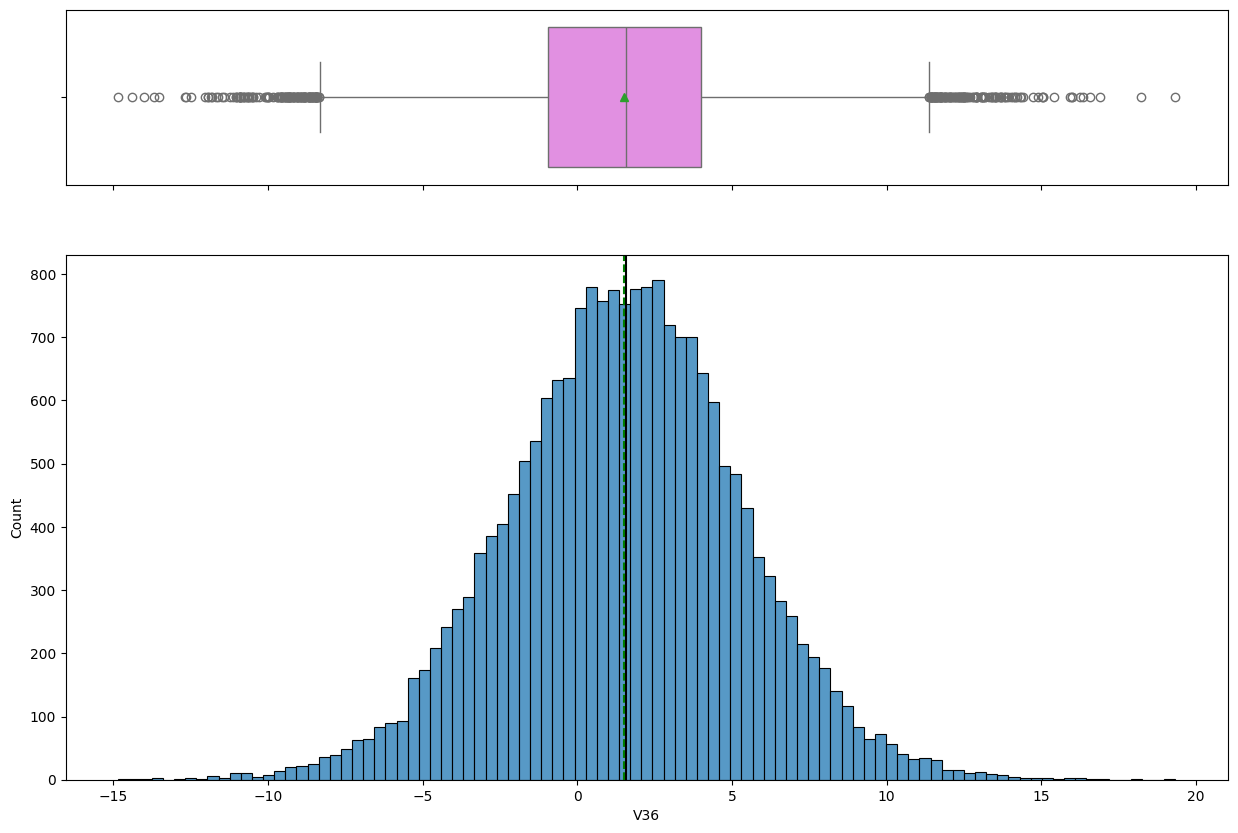

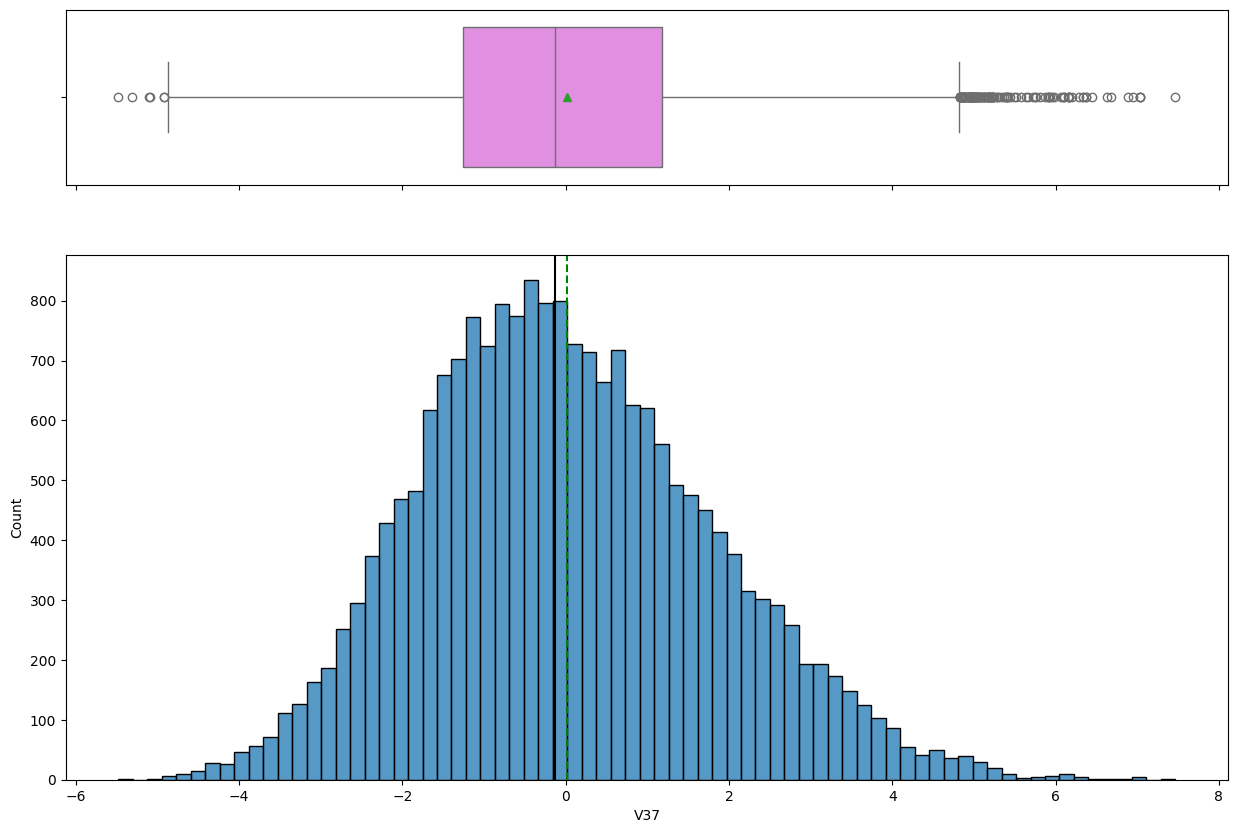

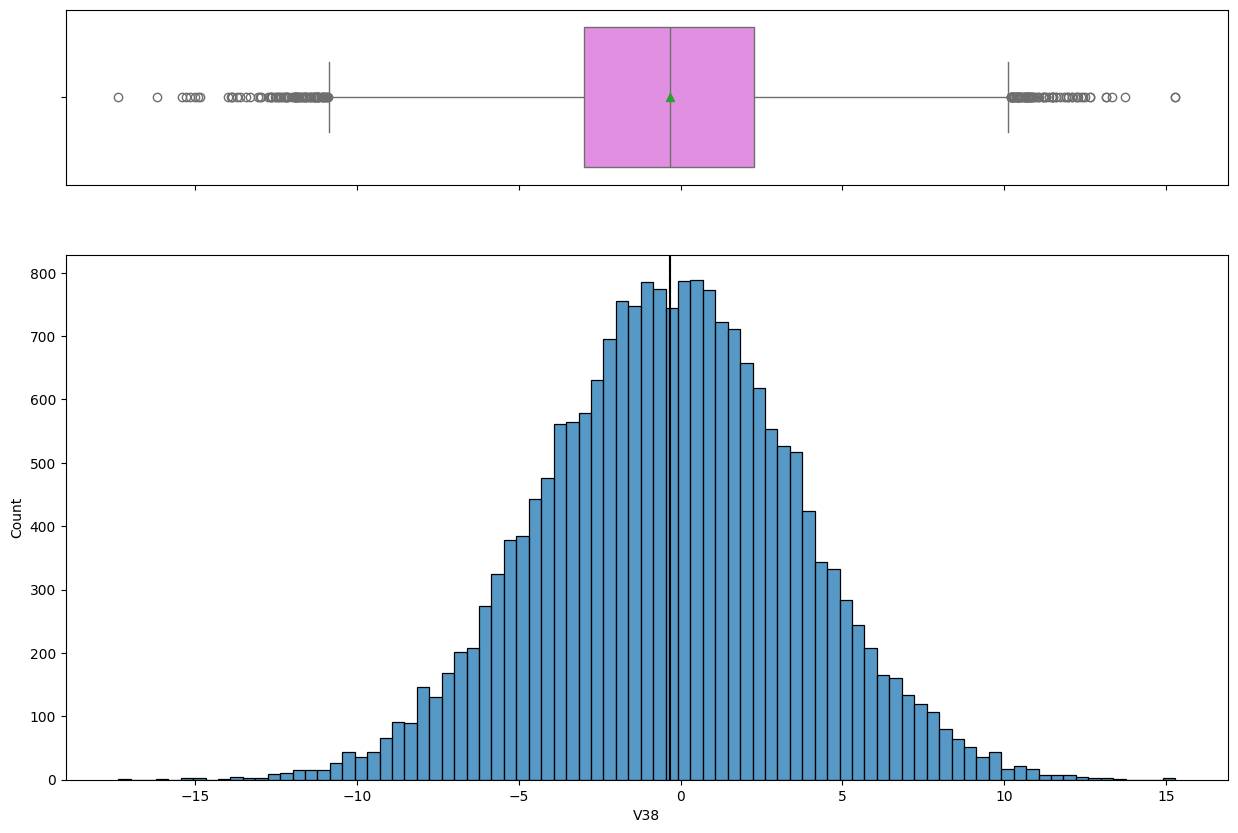

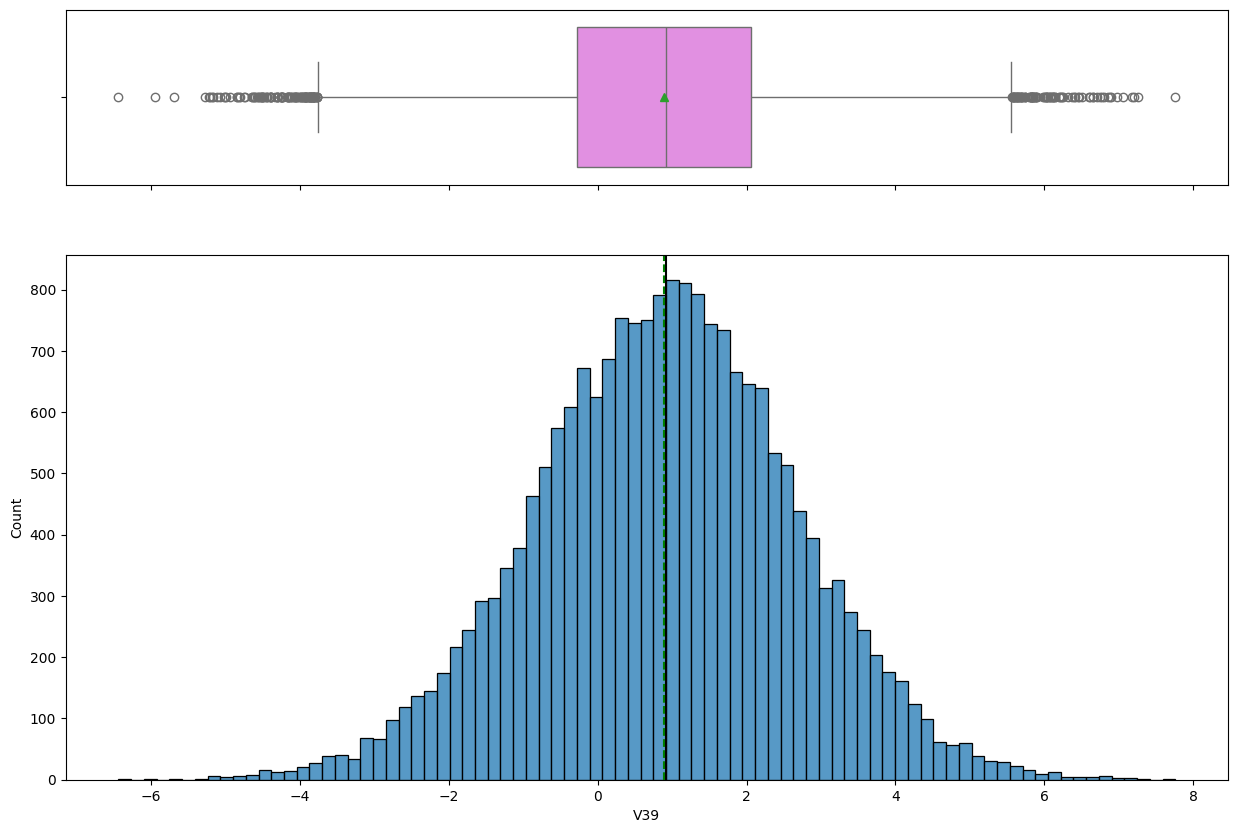

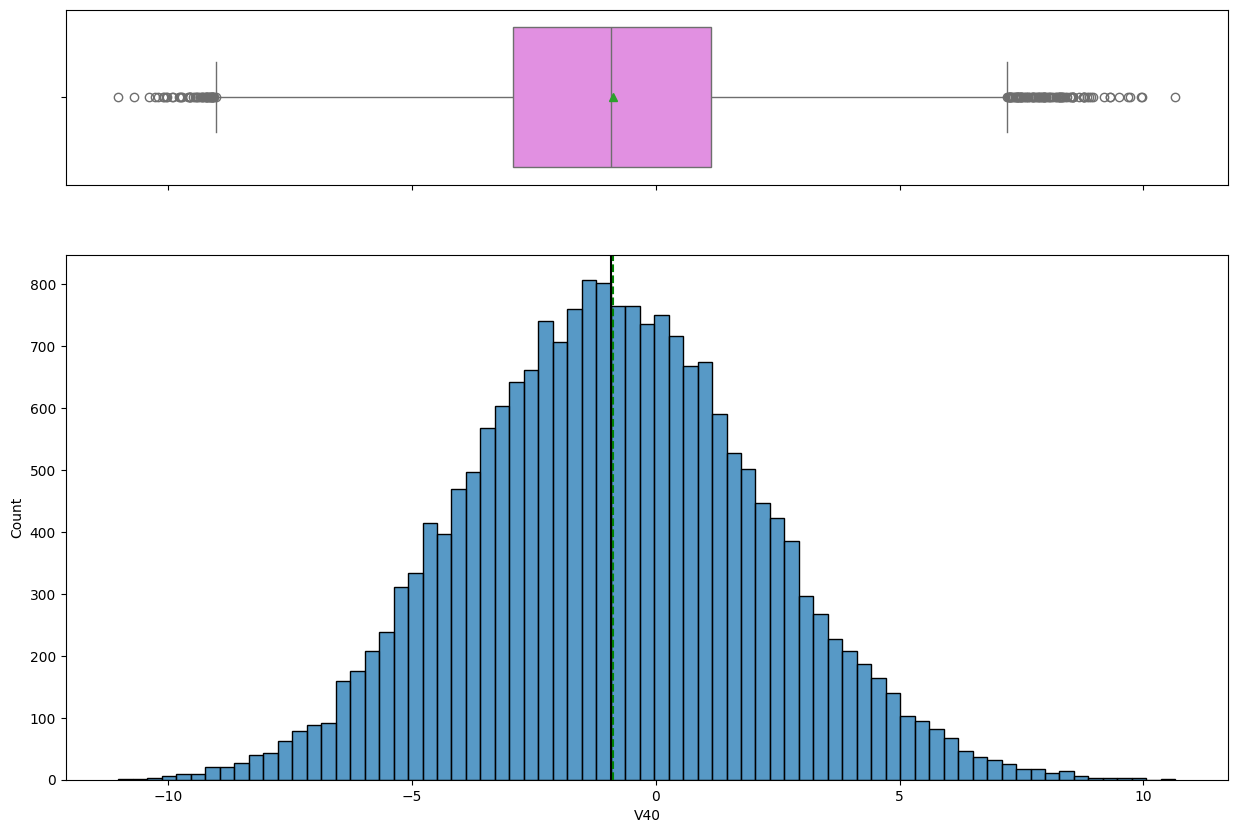

In [326]:
for feature in data.columns[:-1]:
  histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None)

- All predictor variables are normally distributed

### Target Variable Distribution

<Axes: xlabel='Target', ylabel='percent'>

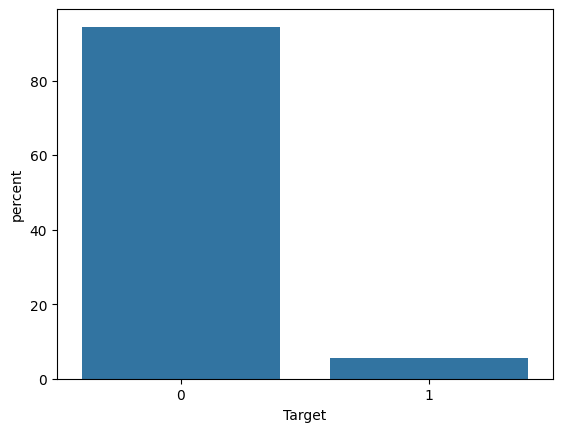

In [327]:
sns.countplot(x="Target", data=data, stat='percent')


In [328]:
data['Target'].value_counts(1)

,proportion
Target,
0,0.9445
1,0.0555


In [329]:
data_test['Target'].value_counts(1)

,proportion
Target,
0,0.9436
1,0.0564


* The dataset is highly imbalanced, with about 94% class 0 and 6% class 1.
* The positive (minority) class represents only a small portion of the data (~5.5%).
* The class distribution is consistent across both samples shown.


## Bivariate Analysis

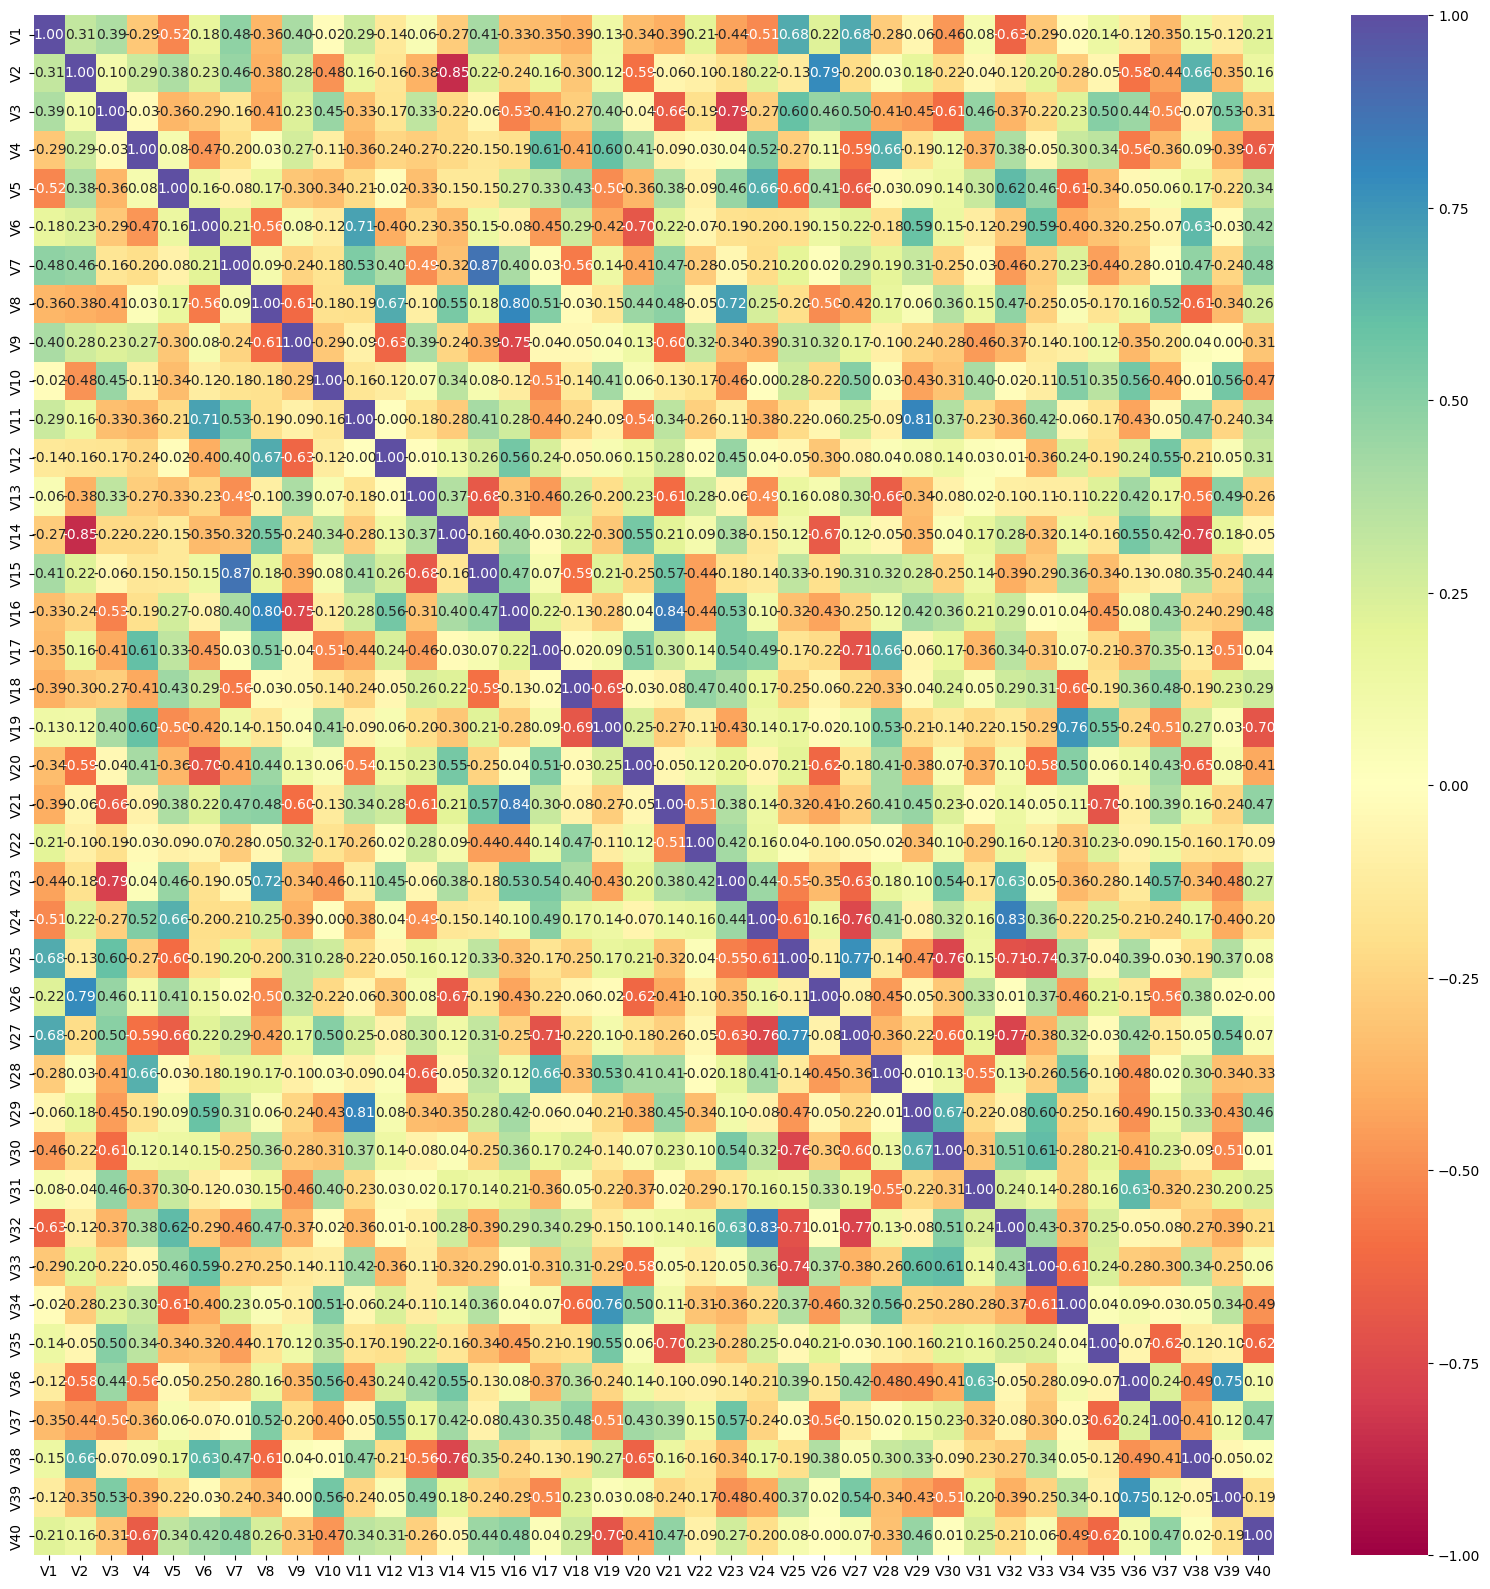

In [330]:
# defining the size of the plot
plt.figure(figsize=(20, 20))
num_features = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_features.remove('Target')

# plotting the heatmap for correlation
sns.heatmap(
    data[num_features].corr(),annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
);

# **Data Preprocessing**

In [331]:
# Dividing into X and y
X = data.drop(['Target'], axis=1)
y = data['Target']

not necessary since we have train and test data given

In [332]:
# training and validation set
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.25, random_state=1, stratify=y
)

In [333]:
# Checking the number of rows and columns in the X_train data
X_train.shape

(15000, 40)

In [334]:
X_val.shape

(5000, 40)

In [335]:
# Dividing test data
X_test = data_test.drop(['Target'], axis=1)
y_test = data_test['Target']

In [336]:
X_test.shape

(5000, 40)

### Missing Value Imputation

There were missing values in V1 and V2. we will impute the missing values using the median

In [337]:
imputer = SimpleImputer(strategy="median")

In [338]:
# fit and transform the train data
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)

# Validation Data
X_val = pd.DataFrame(imputer.transform(X_val), columns=X_val.columns)

# Test Data
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

In [339]:
# Checking that no column has no missing values in all data sets
print(X_train.isna().sum())
print("-"*30)
print(X_val.isna().sum())
print("-"*30)
print(X_test.isna().sum())

V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22    0
V23    0
V24    0
V25    0
V26    0
V27    0
V28    0
V29    0
V30    0
V31    0
V32    0
V33    0
V34    0
V35    0
V36    0
V37    0
V38    0
V39    0
V40    0
dtype: int64
------------------------------
V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22    0
V23    0
V24    0
V25    0
V26    0
V27    0
V28    0
V29    0
V30    0
V31    0
V32    0
V33    0
V34    0
V35    0
V36    0
V37    0
V38    0
V39    0
V40    0
dtype: int64
------------------------------
V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22

# **Model Building**

## Model Evaluation Criterion

Because different prediction outcomes have **different financial impacts**, the evaluation metric should directly reflect **business cost**, not just statistical accuracy.

---

### **Cost Hierarchy (Given)**

* **False Negative (FN)** → Replacement cost → **Highest cost**
* **True Positive (TP)** → Repair cost → Moderate cost
* **False Positive (FP)** → Inspection cost → Low cost
* **True Negative (TN)** → No cost

Since:
Replacement cost > Repair cost > Inspection cost

The most critical error to avoid is **False Negatives (missed failures)**.

---

### **Recommended Evaluation Criterion**

The best model is the one that **minimizes total operational cost**, not necessarily the one with highest accuracy.

The appropriate evaluation criterion is **cost-sensitive evaluation by minimizing total expected cost**, because false negatives (missed failures) are significantly more expensive than false positives or repairs. This ensures the model aligns with the company’s business objective of reducing overall maintenance cost rather than simply maximizing predictive accuracy.


We define a utility function to collate all the metrics into a single data frame, and another to plot the confusion matrix.

In [340]:
def model_performance_classification(model, predictors, target, threshold=0.5):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors) > threshold

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred, average='macro')  # to compute Precision
    f1 = f1_score(target, pred, average='macro')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [341]:
def plot(history, name):
  """
  Function to plot loss/accuracy

  #history: an object which stores the metrics and losses.
  #name: can be one of Loss or Accuracy
  """

  fig, ax = plt.subplots() #Creating a subplot with figure and axes.
  plt.plot(history.history[name]) #Plotting the train accuracy or train loss
  plt.plot(history.history['val_'+name]) #Plotting the validation accuracy or validation loss

  plt.title('Model ' + name.capitalize()) #Defining the title of the plot.
  plt.ylabel(name.capitalize()) #Capitalizing the first letter.
  plt.xlabel('Epoch') #Defining the label for the x-axis.
  fig.legend(['Train', 'Validation'], loc="outside right upper") #Defining the legend, loc controls the position of the legend.



## Initial Model Building (Model 0)

- Let's start with a neural network consisting of
  - just one hidden layer
  - activation function of ReLU
  - SGD as the optimizer

In [342]:
#definitions
epochs = 25
batch_size = 64

In [343]:
# clear current session
tf.keras.backend.clear_session()

In [344]:
#Initialization
model_0 = Sequential()
model_0.add(Dense(7, activation='relu', input_dim=X_train.shape[1]))
model_0.add(Dense(1, activation='sigmoid'))

In [345]:
model_0.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 7)              │           287 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 295 (1.15 KB)

 Trainable params: 295 (1.15 KB)

 Non-trainable params: 0 (0.00 B)

In [346]:
optmizer = tf.keras.optimizers.SGD()
model_0.compile(loss='binary_crossentropy', optimizer=optmizer, metrics=['Recall'])

In [347]:
start = time.time()
history = model_0.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_val, y_val))
end = time.time()

Epoch 1/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.1920 - loss: 0.1870 - val_Recall: 0.4173 - val_loss: 0.1230
Epoch 2/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.4778 - loss: 0.1168 - val_Recall: 0.5108 - val_loss: 0.1087
Epoch 3/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Recall: 0.5315 - loss: 0.1028 - val_Recall: 0.5576 - val_loss: 0.1026
Epoch 4/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Recall: 0.5829 - loss: 0.0895 - val_Recall: 0.5971 - val_loss: 0.0986
Epoch 5/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Recall: 0.6282 - loss: 0.0860 - val_Recall: 0.6295 - val_loss: 0.0954
Epoch 6/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.6632 - loss: 0.0810 - val_Recall: 0.6367 - val_loss: 0.0932
Epoch 7/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.6501 - loss: 0.0824 - val_Recall: 0.6475 - val_loss: 0.0909
Epoch 8/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.6112 - loss: 0.0887 - val_Recall: 0.6583 - val_loss: 0.0894
Epoch 9/

In [348]:
print("Time taken to train the model: ", end - start, "seconds")

Time taken to train the model:  18.83494472503662 seconds


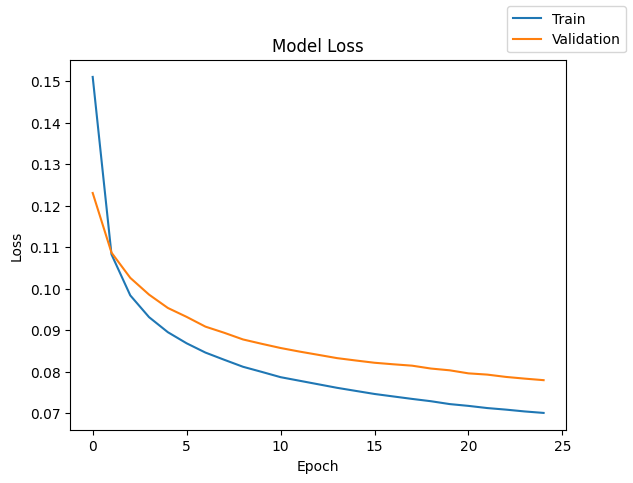

In [349]:
plot(history, 'loss')

In [350]:
model_0_train_perf = model_performance_classification(model_0, X_train, y_train)
model_0_train_perf

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1
0,0.983467,0.730769,0.973218,0.910955


In [351]:
model_0_val_perf = model_performance_classification(model_0, X_val, y_val)
model_0_val_perf

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


,Accuracy,Recall,Precision,F1
0,0.9822,0.715827,0.967832,0.903946


In [352]:
y_train_pred = model_0.predict(X_train)
y_val_pred = model_0.predict(X_val)

469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 997us/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [353]:
print(classification_report(y_train, y_train_pred > 0.5))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     14168
           1       0.96      0.73      0.83       832

    accuracy                           0.98     15000
   macro avg       0.97      0.86      0.91     15000
weighted avg       0.98      0.98      0.98     15000



The model performs excellently on the majority class but struggles with recall for the minority class.

Macro average (0.96 precision, 0.84 recall, 0.89 F1) gives equal weight to both classes → highlights the weaker performance on class 1.

Weighted average (0.98 across the board) is dominated by class 0 due to class imbalance.

# **Model Performance Improvement**

## Model 1

In [354]:
#Clear current session
tf.keras.backend.clear_session()

In [355]:
#Initialization
model_1 = Sequential()
model_1.add(Dense(14, activation='relu', input_dim=X_train.shape[1]))
model_1.add(Dense(7, activation='relu'))
model_1.add(Dense(1, activation='sigmoid'))

In [356]:
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 14)             │           574 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 687 (2.68 KB)

 Trainable params: 687 (2.68 KB)

 Non-trainable params: 0 (0.00 B)

In [357]:
optmizer = tf.keras.optimizers.SGD()
model_1.compile(loss='binary_crossentropy', optimizer=optmizer, metrics=['Recall'])

In [358]:
start = time.time()
history = model_1.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_val, y_val))
end = time.time()

Epoch 1/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.0363 - loss: 0.2918 - val_Recall: 0.0108 - val_loss: 0.1659
Epoch 2/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.0365 - loss: 0.1521 - val_Recall: 0.0935 - val_loss: 0.1367
Epoch 3/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.1760 - loss: 0.1282 - val_Recall: 0.2986 - val_loss: 0.1235
Epoch 4/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.3794 - loss: 0.1106 - val_Recall: 0.4892 - val_loss: 0.1150
Epoch 5/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.4618 - loss: 0.1093 - val_Recall: 0.5612 - val_loss: 0.1103
Epoch 6/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.5631 - loss: 0.1066 - val_Recall: 0.5719 - val_loss: 0.1060
Epoch 7/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.5532 - loss: 0.1137 - val_Recall: 0.6079 - val_loss: 0.1023
Epoch 8/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.6337 - loss: 0.0887 - val_Recall: 0.6403 - val_loss: 0.0985
Epoch 9/

In [359]:
print("Time taken to train the model: ", end - start, "seconds")

Time taken to train the model:  17.434306859970093 seconds


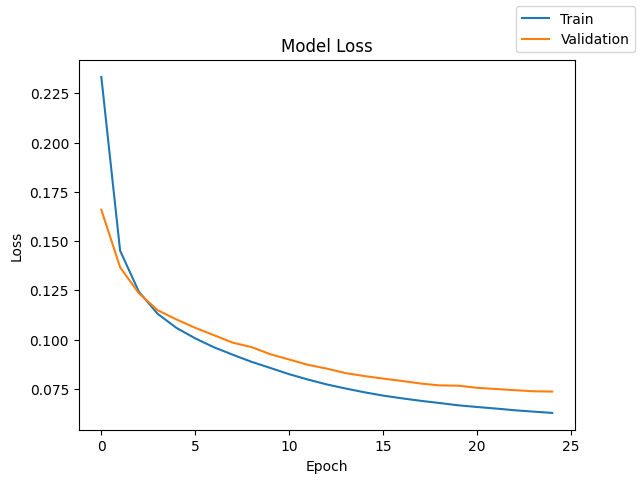

In [360]:
plot(history, 'loss')

In [361]:
model_1_train_perf = model_performance_classification(model_1, X_train, y_train)
model_1_train_perf

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1
0,0.985867,0.78125,0.971586,0.926173


In [362]:
model_1_val_perf = model_performance_classification(model_1, X_val, y_val)
model_1_val_perf

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


,Accuracy,Recall,Precision,F1
0,0.9846,0.76259,0.968428,0.919101


In [363]:
y_train_pred_1 = model_1.predict(X_train)
y_val_pred_1 = model_1.predict(X_val)

469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 989us/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [364]:
print(classification_report(y_train, y_train_pred_1 > 0.5))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     14168
           1       0.96      0.78      0.86       832

    accuracy                           0.99     15000
   macro avg       0.97      0.89      0.93     15000
weighted avg       0.99      0.99      0.99     15000



In [365]:
print(classification_report(y_val, y_val_pred_1 > 0.5))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4722
           1       0.95      0.76      0.85       278

    accuracy                           0.98      5000
   macro avg       0.97      0.88      0.92      5000
weighted avg       0.98      0.98      0.98      5000



Model 1 performs better overall, as it detects the minority class more effectively, slightly improves performance on the majority class, and achieves a more balanced performance across all classes.

## Model 2

In [366]:
#Clear current session
tf.keras.backend.clear_session()

In [367]:
#Initialization
from tensorflow.keras.layers import Dropout
model_2 = Sequential()
model_2.add(Dense(14, activation='relu', input_dim=X_train.shape[1]))
model_2.add(Dropout(0.5))
model_2.add(Dense(7, activation='relu'))
model_2.add(Dense(3, activation='relu'))
model_2.add(Dense(1, activation='sigmoid'))

In [368]:
model_2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 14)             │           574 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 707 (2.76 KB)

 Trainable params: 707 (2.76 KB)

 Non-trainable params: 0 (0.00 B)

In [369]:
optmizer = tf.keras.optimizers.SGD()
model_2.compile(loss='binary_crossentropy', optimizer=optmizer, metrics=['Recall'])

In [370]:
start = time.time()
history = model_2.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_val, y_val))
end = time.time()

Epoch 1/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - Recall: 0.0705 - loss: 0.4880 - val_Recall: 0.0000e+00 - val_loss: 0.1730
Epoch 2/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Recall: 0.0000e+00 - loss: 0.2148 - val_Recall: 0.0000e+00 - val_loss: 0.1563
Epoch 3/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Recall: 0.0000e+00 - loss: 0.1983 - val_Recall: 0.0000e+00 - val_loss: 0.1477
Epoch 4/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.0000e+00 - loss: 0.1780 - val_Recall: 0.0000e+00 - val_loss: 0.1438
Epoch 5/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.0000e+00 - loss: 0.1750 - val_Recall: 0.0000e+00 - val_loss: 0.1404
Epoch 6/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.0000e+00 - loss: 0.1605 - val_Recall: 0.0000e+00 - val_loss: 0.1385
Epoch 7/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.0000e+00 - loss: 0.1545 - val_Recall: 0.0000e+00 - val_loss: 0.1360
Epoch 8/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.0000e+00 - loss:

In [371]:
print("Time taken to train the model: ", end - start, "seconds")

Time taken to train the model:  19.725871086120605 seconds


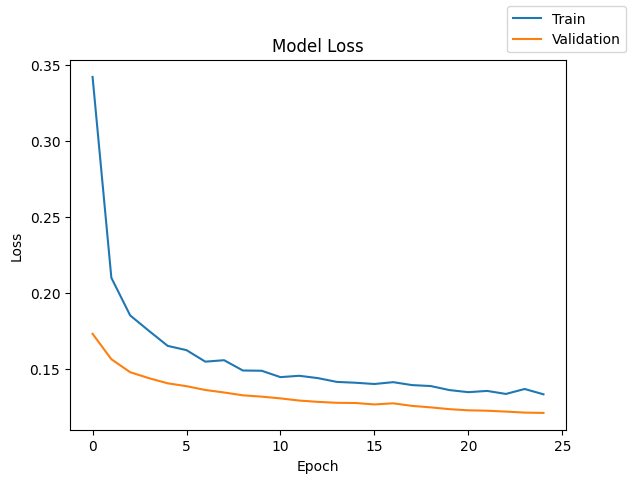

In [372]:
plot(history, 'loss')

In [373]:
model_2_train_perf = model_performance_classification(model_2, X_train, y_train)
model_2_train_perf

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1
0,0.944533,0.0,0.472267,0.485738


In [374]:
model_2_val_perf = model_performance_classification(model_2, X_val, y_val)
model_2_val_perf

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1
0,0.9444,0.0,0.4722,0.485703


In [375]:
y_train_pred_2 = model_2.predict(X_train)
y_val_pred_2 = model_2.predict(X_val)

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [376]:
print(classification_report(y_train, y_train_pred_2 > 0.5))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97     14168
           1       0.00      0.00      0.00       832

    accuracy                           0.94     15000
   macro avg       0.47      0.50      0.49     15000
weighted avg       0.89      0.94      0.92     15000



In [377]:
print(classification_report(y_val, y_val_pred_2 > 0.5))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97      4722
           1       0.00      0.00      0.00       278

    accuracy                           0.94      5000
   macro avg       0.47      0.50      0.49      5000
weighted avg       0.89      0.94      0.92      5000



## Model 3

In [378]:
# Calculate class weights for imbalanced dataset
cw = (y_train.shape[0]) / np.bincount(y_train.astype(int)) # Convert y_train to integers

# Create a dictionary mapping class indices to their respective class weights
cw_dict = {}
for i in range(cw.shape [0]):
  cw_dict[i] = cw[i]

cw_dict

{0: np.float64(1.0587238848108413), 1: np.float64(18.028846153846153)}

In [379]:
#Clear current session
tf.keras.backend.clear_session()

In [380]:
#Initialization
from tensorflow.keras.layers import Dropout
model_3 = Sequential()
model_3.add(Dense(14, activation='relu', input_dim=X_train.shape[1]))
model_3.add(Dropout(0.5))
model_3.add(Dense(7, activation='relu'))
model_3.add(Dense(3, activation='relu'))
model_3.add(Dense(1, activation='sigmoid'))

In [381]:
from tensorflow.keras.layers import Dropout
model_3 = Sequential()
model_3.add(Dense(64, activation='relu', input_dim=X_train.shape[1]))
model_3.add(Dropout(0.8))
model_3.add(Dense(32, activation='relu'))
model_3.add(Dense(1, activation='sigmoid'))

In [382]:
model_3.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

In [383]:
optmizer = tf.keras.optimizers.SGD()
model_3.compile(loss='binary_crossentropy', optimizer=optmizer, metrics=['Recall'])

In [384]:
start = time.time()
history = model_3.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_val, y_val), class_weight = cw_dict)
end = time.time()

Epoch 1/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - Recall: 0.6703 - loss: 1.7198 - val_Recall: 0.9065 - val_loss: 0.4568
Epoch 2/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.8144 - loss: 0.9159 - val_Recall: 0.8633 - val_loss: 0.2908
Epoch 3/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.8104 - loss: 0.7869 - val_Recall: 0.8705 - val_loss: 0.2948
Epoch 4/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.8336 - loss: 0.7449 - val_Recall: 0.8561 - val_loss: 0.1968
Epoch 5/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.8235 - loss: 0.7552 - val_Recall: 0.8597 - val_loss: 0.2849
Epoch 6/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.8256 - loss: 0.7578 - val_Recall: 0.8525 - val_loss: 0.1980
Epoch 7/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.8253 - loss: 0.6544 - val_Recall: 0.8669 - val_loss: 0.2531
Epoch 8/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - Recall: 0.8146 - loss: 0.6740 - val_Recall: 0.8633 - val_loss: 0.2420
Epoch 9/

In [385]:
print("Time taken to train the model: ", end - start, "seconds")

Time taken to train the model:  21.551206350326538 seconds


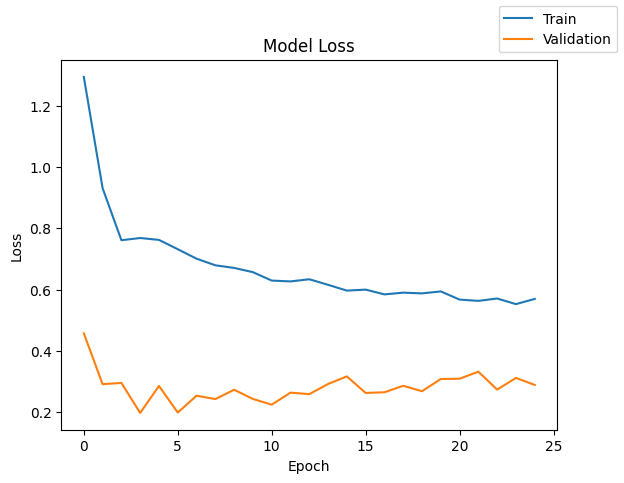

In [386]:
plot(history, 'loss')

In [387]:
model_3_train_perf = model_performance_classification(model_3, X_train, y_train)
model_3_train_perf

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


,Accuracy,Recall,Precision,F1
0,0.977333,0.883413,0.872308,0.900047


In [388]:
model_3_val_perf = model_performance_classification(model_3, X_val, y_val)
model_3_val_perf

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy,Recall,Precision,F1
0,0.9758,0.859712,0.868107,0.892563


In [389]:
y_train_pred_3 = model_3.predict(X_train)
y_val_pred_3 = model_3.predict(X_val)

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [390]:
print(classification_report(y_train, y_train_pred_3 > 0.5))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99     14168
           1       0.75      0.88      0.81       832

    accuracy                           0.98     15000
   macro avg       0.87      0.93      0.90     15000
weighted avg       0.98      0.98      0.98     15000



In [391]:
print(classification_report(y_val, y_val_pred_3 > 0.5))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4722
           1       0.74      0.86      0.80       278

    accuracy                           0.98      5000
   macro avg       0.87      0.92      0.89      5000
weighted avg       0.98      0.98      0.98      5000



## Model 4

In [392]:
#Clear current session
tf.keras.backend.clear_session()

In [393]:
#Initialization
model_4 = Sequential()
model_4.add(Dense(14, activation='relu', input_dim=X_train.shape[1]))
model_4.add(Dense(7, activation='relu'))
model_4.add(Dense(1, activation='sigmoid'))

In [394]:
model_4.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 14)             │           574 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 687 (2.68 KB)

 Trainable params: 687 (2.68 KB)

 Non-trainable params: 0 (0.00 B)

In [395]:
optmizer = tf.keras.optimizers.Adam()
model_4.compile(loss='binary_crossentropy', optimizer=optmizer, metrics=['Recall'])

In [396]:
start = time.time()
history = model_4.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_val, y_val))
end = time.time()

Epoch 1/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - Recall: 0.4065 - loss: 0.2217 - val_Recall: 0.5647 - val_loss: 0.1127
Epoch 2/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.5620 - loss: 0.0989 - val_Recall: 0.6403 - val_loss: 0.0964
Epoch 3/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.7075 - loss: 0.0723 - val_Recall: 0.7158 - val_loss: 0.0858
Epoch 4/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.7214 - loss: 0.0772 - val_Recall: 0.7266 - val_loss: 0.0776
Epoch 5/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.7719 - loss: 0.0666 - val_Recall: 0.7662 - val_loss: 0.0744
Epoch 6/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.7997 - loss: 0.0557 - val_Recall: 0.7734 - val_loss: 0.0690
Epoch 7/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.7853 - loss: 0.0652 - val_Recall: 0.8201 - val_loss: 0.0673
Epoch 8/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.7968 - loss: 0.0583 - val_Recall: 0.7914 - val_loss: 0.0638
Epoch 9/

In [397]:
print("Time taken to train the model: ", end - start, "seconds")

Time taken to train the model:  20.872010707855225 seconds


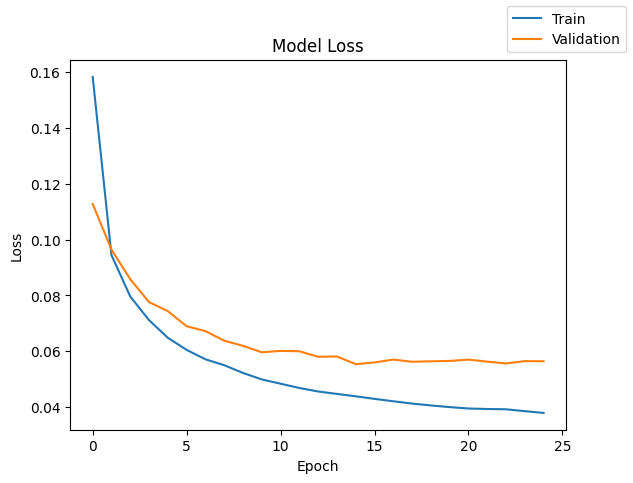

In [398]:
plot(history, 'loss')

In [399]:
model_4_train_perf = model_performance_classification(model_4, X_train, y_train)
model_4_train_perf

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1
0,0.9928,0.883413,0.989225,0.96388


In [400]:
model_4_val_perf = model_performance_classification(model_4, X_val, y_val)
model_4_val_perf

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


,Accuracy,Recall,Precision,F1
0,0.9904,0.852518,0.981345,0.951491


In [401]:
y_train_pred_4 = model_4.predict(X_train)
y_val_pred_4 = model_4.predict(X_val)

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [402]:
print(classification_report(y_train, y_train_pred_4 > 0.5))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     14168
           1       0.99      0.88      0.93       832

    accuracy                           0.99     15000
   macro avg       0.99      0.94      0.96     15000
weighted avg       0.99      0.99      0.99     15000



In [403]:
print(classification_report(y_val, y_val_pred_4 > 0.5))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4722
           1       0.97      0.85      0.91       278

    accuracy                           0.99      5000
   macro avg       0.98      0.93      0.95      5000
weighted avg       0.99      0.99      0.99      5000



## Model 5

In [404]:
#Clear current session
tf.keras.backend.clear_session()

In [405]:
#Initialization
from tensorflow.keras.layers import Dropout
model_5 = Sequential()
model_5.add(Dense(14, activation='relu', input_dim=X_train.shape[1]))
model_5.add(Dropout(0.5))
model_5.add(Dense(7, activation='relu'))
model_5.add(Dense(3, activation='relu'))
model_5.add(Dense(1, activation='sigmoid'))

In [406]:
model_5.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 14)             │           574 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 707 (2.76 KB)

 Trainable params: 707 (2.76 KB)

 Non-trainable params: 0 (0.00 B)

In [407]:
optmizer = tf.keras.optimizers.Adam()
model_5.compile(loss='binary_crossentropy', optimizer=optmizer, metrics=['Recall'])

In [408]:
start = time.time()
history = model_5.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_val, y_val))
end = time.time()

Epoch 1/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - Recall: 0.3384 - loss: 0.5258 - val_Recall: 0.0036 - val_loss: 0.1567
Epoch 2/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.0931 - loss: 0.1829 - val_Recall: 0.3381 - val_loss: 0.1261
Epoch 3/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.3419 - loss: 0.1490 - val_Recall: 0.5863 - val_loss: 0.1063
Epoch 4/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.5230 - loss: 0.1235 - val_Recall: 0.6547 - val_loss: 0.0951
Epoch 5/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.5683 - loss: 0.1130 - val_Recall: 0.6691 - val_loss: 0.0889
Epoch 6/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.5933 - loss: 0.0984 - val_Recall: 0.7014 - val_loss: 0.0849
Epoch 7/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.5786 - loss: 0.1050 - val_Recall: 0.7194 - val_loss: 0.0810
Epoch 8/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.5814 - loss: 0.1043 - val_Recall: 0.7266 - val_loss: 0.0794
Epoch 9/

In [409]:
print("Time taken to train the model: ", end - start, "seconds")

Time taken to train the model:  21.105480194091797 seconds


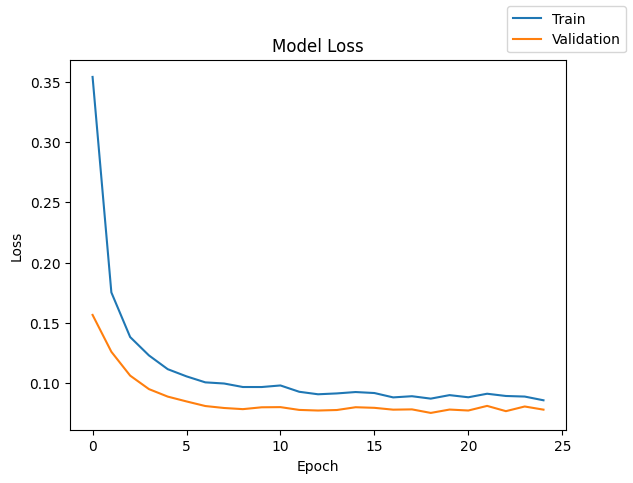

In [410]:
plot(history, 'loss')

In [411]:
model_5_train_perf = model_performance_classification(model_5, X_train, y_train)
model_5_train_perf

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1
0,0.981067,0.663462,0.98671,0.892732


In [412]:
model_5_val_perf = model_performance_classification(model_5, X_val, y_val)
model_5_val_perf

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


,Accuracy,Recall,Precision,F1
0,0.9832,0.71223,0.981762,0.908088


In [413]:
y_train_pred_5 = model_5.predict(X_train)
y_val_pred_5 = model_5.predict(X_val)

469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 994us/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [414]:
print(classification_report(y_train, y_train_pred_5 > 0.5))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     14168
           1       0.99      0.66      0.80       832

    accuracy                           0.98     15000
   macro avg       0.99      0.83      0.89     15000
weighted avg       0.98      0.98      0.98     15000



In [415]:
print(classification_report(y_val, y_val_pred_5 > 0.5))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      4722
           1       0.98      0.71      0.82       278

    accuracy                           0.98      5000
   macro avg       0.98      0.86      0.91      5000
weighted avg       0.98      0.98      0.98      5000



## Model 6

In [416]:
#Clear current session
tf.keras.backend.clear_session()

In [417]:
#Initialization
from tensorflow.keras.layers import Dropout
model_6 = Sequential()
model_6.add(Dense(14, activation='relu', input_dim=X_train.shape[1]))
model_6.add(Dropout(0.5))
model_6.add(Dense(7, activation='relu'))
model_6.add(Dense(1, activation='sigmoid'))

In [418]:
model_6.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 14)             │           574 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 687 (2.68 KB)

 Trainable params: 687 (2.68 KB)

 Non-trainable params: 0 (0.00 B)

In [419]:
optmizer = tf.keras.optimizers.Adam()
model_6.compile(loss='binary_crossentropy', optimizer=optmizer, metrics=['Recall'])

In [420]:
start = time.time()
history = model_6.fit(X_train, y_train, epochs=epochs, batch_size=30, validation_data=(X_val, y_val))
end = time.time()

Epoch 1/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - Recall: 0.4548 - loss: 0.8261 - val_Recall: 0.3309 - val_loss: 0.1266
Epoch 2/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - Recall: 0.3632 - loss: 0.1707 - val_Recall: 0.4353 - val_loss: 0.1106
Epoch 3/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.4154 - loss: 0.1363 - val_Recall: 0.5432 - val_loss: 0.0999
Epoch 4/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.5137 - loss: 0.1242 - val_Recall: 0.5935 - val_loss: 0.0928
Epoch 5/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - Recall: 0.5032 - loss: 0.1191 - val_Recall: 0.6007 - val_loss: 0.0888
Epoch 6/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - Recall: 0.5445 - loss: 0.1110 - val_Recall: 0.6799 - val_loss: 0.0829
Epoch 7/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.5302 - loss: 0.1097 - val_Recall: 0.7338 - val_loss: 0.0791
Epoch 8/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.6033 - loss: 0.0998 - val_Recall: 0.7302 - val_loss: 0.0746
Epoch 9/

In [421]:
print("Time taken to train the model: ", end - start, "seconds")

Time taken to train the model:  38.48211669921875 seconds


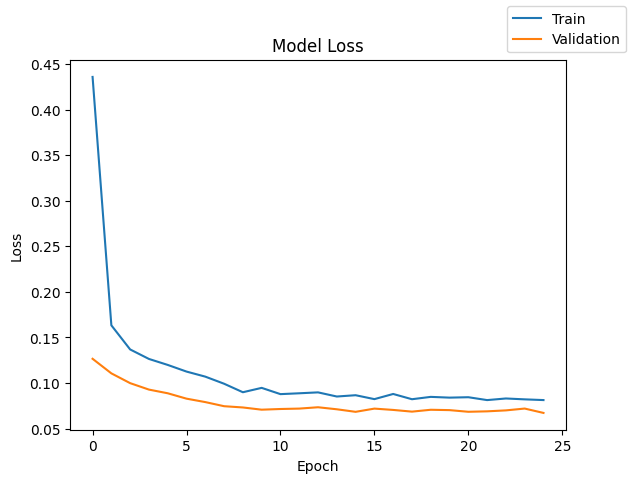

In [422]:
plot(history, 'loss')

In [423]:
model_6_train_perf = model_performance_classification(model_6, X_train, y_train)
model_6_train_perf

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  


,Accuracy,Recall,Precision,F1
0,0.9822,0.682692,0.988225,0.900178


In [424]:
model_6_val_perf = model_performance_classification(model_6, X_val, y_val)
model_6_val_perf

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1
0,0.9834,0.71223,0.984202,0.909002


In [425]:
y_train_pred_6 = model_6.predict(X_train)
y_val_pred_6 = model_6.predict(X_val)

469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [426]:
print(classification_report(y_train, y_train_pred_6 > 0.5))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     14168
           1       0.99      0.68      0.81       832

    accuracy                           0.98     15000
   macro avg       0.99      0.84      0.90     15000
weighted avg       0.98      0.98      0.98     15000



In [427]:
print(classification_report(y_val, y_val_pred_6 > 0.5))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      4722
           1       0.99      0.71      0.83       278

    accuracy                           0.98      5000
   macro avg       0.98      0.86      0.91      5000
weighted avg       0.98      0.98      0.98      5000



# **Model Performance Comparison and Final Model Selection**

Now, in order to select the final model, we will compare the performances of all the models for the training and validation sets.

In [428]:
models_train_compare_difference =  pd.concat(
    [
        model_0_train_perf.T,
        model_1_train_perf.T,
        model_2_train_perf.T,
        model_3_train_perf.T,
        model_4_train_perf.T,
        model_5_train_perf.T,
        model_6_train_perf.T
    ],
    axis = 1
)

models_train_compare_difference.columns =  [
    "Model 0",
    "Model 1",
    "Model 2",
    "Model 3",
    "Model 4",
    "Model 5",
    "Model 6"
]

print("Training set performance comparison")
models_train_compare_difference


Training set performance comparison


,Model 0,Model 1,Model 2,Model 3,Model 4,Model 5,Model 6
Accuracy,0.983467,0.985867,0.944533,0.977333,0.992800,0.981067,0.982200
Recall,0.730769,0.781250,0.000000,0.883413,0.883413,0.663462,0.682692
Precision,0.973218,0.971586,0.472267,0.872308,0.989225,0.986710,0.988225
F1,0.910955,0.926173,0.485738,0.900047,0.963880,0.892732,0.900178


In [429]:
models_val_compare_difference =  pd.concat(
    [
        model_0_val_perf.T,
        model_1_val_perf.T,
        model_2_val_perf.T,
        model_3_val_perf.T,
        model_4_val_perf.T,
        model_5_val_perf.T,
        model_6_val_perf.T
    ],
    axis = 1
)

models_val_compare_difference.columns =  [
    "Model 0",
    "Model 1",
    "Model 2",
    "Model 3",
    "Model 4",
    "Model 5",
    "Model 6"
]

print("Validation set performance comparison")
models_val_compare_difference


Validation set performance comparison


,Model 0,Model 1,Model 2,Model 3,Model 4,Model 5,Model 6
Accuracy,0.982200,0.984600,0.944400,0.975800,0.990400,0.983200,0.983400
Recall,0.715827,0.762590,0.000000,0.859712,0.852518,0.712230,0.712230
Precision,0.967832,0.968428,0.472200,0.868107,0.981345,0.981762,0.984202
F1,0.903946,0.919101,0.485703,0.892563,0.951491,0.908088,0.909002


Now, let's check the performance of the final model on the test set.

In [430]:
best_model = model_4

**Model 4 is the bset model**

Because it:

- Has the best overall validation F1-score

- Has the highest accuracy

- Maintains excellent precision

- Shows stable train vs validation performance

- Provides the best balance between false positives and false negatives

In [431]:
best_model_test_performance =  model_performance_classification(best_model, X_test, y_test)
best_model_test_performance

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1
0,0.9898,0.858156,0.974048,0.949642


In [432]:
y_test_pred_best =  best_model.predict(X_test)

print(classification_report(y_test, y_test_pred_best > 0.5))

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4718
           1       0.96      0.86      0.90       282

    accuracy                           0.99      5000
   macro avg       0.97      0.93      0.95      5000
weighted avg       0.99      0.99      0.99      5000



# **Actionable Insights and Recommendations**

Write down some insights and business recommendations based on your observations.

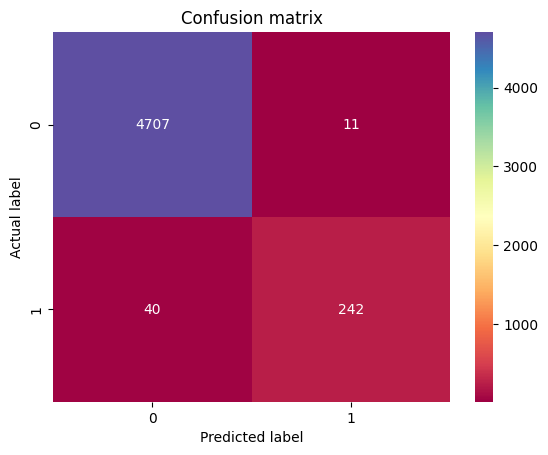

In [433]:
cm = confusion_matrix(y_test, y_test_pred_best > 0.5)
sns.heatmap(cm, annot=True, fmt='g', cmap='Spectral')
plt.title('Confusion matrix')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

### 📊 Confusion Matrix Summary

* **TN:** 4707
* **FP:** 11
* **FN:** 40
* **TP:** 242
* **Total:** 5000

### 📈 Key Metrics

* **Accuracy:** 98.98%
* **Precision:** 95.65%
* **Recall:** 85.82%
* **F1-score:** ~0.90

---

### 🔎 Key Insights

* Very **high overall accuracy**.
* **Recall improved** (fewer missed positives: 40 vs 43 previously).
* Slight increase in **false positives** (11 instead of 5).
* Better balance between precision and recall.

---

### 🎯 Recommendation

This model is slightly more **recall-focused**, making it preferable if:

* Missing positive cases is costly.

If minimizing false alarms is more important, the previous version (with only 5 FP) is better.

Overall: **Stronger balance, better for risk-sensitive applications.**
